# DX 602 Final Project

## Introduction

In this project, you will practice the skills that you have learned throughout this module with a heavy focus on building models.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform build models, run a computation, or otherwise perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
The Thanksgiving holiday was also taken into account in setting the deadline.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [327]:
import math
import sys

In [328]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D 
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - red subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_red))
* [Body Fat](https://www.openml.org/search?type=data&status=active&id=560) ([PMLB](https://github.com/EpistasisLab/pmlb/tree/master/datasets/560_bodyfat))

The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the dataset has missing data, you should drop the rows with missing data before proceeding.
If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [329]:
# YOUR CODE HERE
# url for Body Fat data set
url = "https://github.com/EpistasisLab/pmlb/raw/refs/heads/master/datasets/560_bodyfat/560_bodyfat.tsv.gz"
df = pd.read_csv(url, sep="\t", compression="gzip")
df.sample(n=10)

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
24,1.0668,28.0,151.25,67.75,34.5,90.2,76.3,95.8,58.4,35.5,22.9,31.1,28.0,17.6,14.0
45,1.0670,43.0,164.25,73.25,35.7,96.6,81.5,97.2,58.4,38.2,23.4,29.7,27.4,18.3,13.9
20,1.0551,28.0,179.00,68.00,39.1,103.3,95.9,104.9,63.5,38.0,22.1,32.5,30.3,18.4,19.1
11,1.0812,27.0,216.00,76.00,39.4,103.6,90.9,107.7,66.2,39.2,25.9,37.2,30.2,19.0,7.8
238,1.0705,64.0,155.25,69.50,37.9,95.8,82.8,94.5,61.2,39.1,22.3,29.8,28.9,18.3,12.4
58,1.0280,54.0,202.50,70.75,40.5,115.4,105.3,97.0,59.1,38.0,22.5,31.6,28.8,18.2,31.5
147,1.0322,25.0,206.50,69.75,40.9,110.9,100.5,106.2,68.4,40.8,24.6,33.3,29.7,18.4,29.6
233,1.0384,58.0,161.75,67.25,35.1,94.9,94.9,100.2,56.8,35.9,21.0,27.8,26.1,17.6,26.7
145,1.0664,24.0,156.00,70.75,35.7,92.7,81.9,95.3,56.4,36.5,22.0,33.5,28.3,17.3,14.2
56,1.0524,58.0,181.50,68.00,39.1,100.0,99.8,102.5,62.1,39.6,22.5,33.1,28.3,18.5,20.4


Displayed 10 random samples for visalization

### Problem 2 (10 points)

List all of the columns and describe them in your own words.

In [330]:
# YOUR CODE HERE

df.columns

Index(['Density', 'Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip',
       'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist', 'target'],
      dtype='object')



# Column Descriptions:

* **Density** *(continuous)* – Overall body density measured using underwater weighing, expressed in grams per cubic centimeter.
* **Age** *(continuous)* – The person’s age in years.
* **Weight** *(continuous)* – Body weight recorded in pounds.
* **Height** *(continuous)* – Height of the individual measured in inches.
* **Neck** *(continuous)* – Circumference of the neck in centimeters.
* **Chest** *(continuous)* – Circumference of the chest area in centimeters.
* **Abdomen** *(continuous)* – Measurement around the abdomen in centimeters; often strongly related to body fat.
* **Hip** *(continuous)* – Hip circumference in centimeters.
* **Thigh** *(continuous)* – Thigh circumference in centimeters.
* **Knee** *(continuous)* – Knee circumference in centimeters.
* **Ankle** *(continuous)* – Ankle circumference in centimeters.
* **Biceps** *(continuous)* – Upper arm (biceps) circumference measured when the muscle is relaxed.
* **Forearm** *(continuous)* – Forearm circumference in centimeters.
* **Wrist** *(continuous)* – Wrist circumference in centimeters; often used in body composition formulas.
* **target** *(continuous)* – The percentage of body fat for each individual; this is the value we aim to predict.


  

### Problem 3 (50 points)

Perform an exploratory analysis of the data set.
After your exploratory analysis, pick 3 individual charts that you the think were particularly interesting.
Repeat those charts separately from your original analysis, and after each of those charts, explain what you thought was noteworthy.

In [331]:
# YOUR CODE HERE

# ============================================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================================

# Set pandas display options to show more content
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows (or set to a number like 50)
pd.set_option('display.width', None)        # Auto-detect width
pd.set_option('display.max_colwidth', None) # Show full column content
pd.set_option('display.precision', 4)        # Set decimal precision



In [332]:
# ============================================================================
# 1. DATASET OVERVIEW
# ============================================================================
# Purpose: Provide initial dataset inspection including shape, missing values, 
#          and data types
# Uses: None (first section)
# Calculates: None (only displays information)
# ============================================================================

print("=" * 80)
print("1. DATASET OVERVIEW")
print("=" * 80)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Missing values - formatted nicely
print("\n" + "-" * 80)
print("MISSING VALUES PER COLUMN")
print("-" * 80)
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]  # Only show columns with missing values
if len(missing_df) > 0:
    display(missing_df.style.background_gradient(subset=['Missing %'], cmap='Reds'))
else:
    print("✓ No missing values found!")

# Data types - formatted nicely
print("\n" + "-" * 80)
print("DATA TYPES")
print("-" * 80)
dtypes_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values
})
display(dtypes_df.style.set_properties(**{'text-align': 'left'}))

1. DATASET OVERVIEW
Shape: 252 rows × 15 columns

Total missing values: 0

--------------------------------------------------------------------------------
MISSING VALUES PER COLUMN
--------------------------------------------------------------------------------
✓ No missing values found!

--------------------------------------------------------------------------------
DATA TYPES
--------------------------------------------------------------------------------


,Column,Data Type,Non-Null Count
0,Density,float64,252
1,Age,float64,252
2,Weight,float64,252
3,Height,float64,252
4,Neck,float64,252
5,Chest,float64,252
6,Abdomen,float64,252
7,Hip,float64,252
8,Thigh,float64,252
9,Knee,float64,252


**1. Dataset Overview**

To start the analysis, I first took a broad look at the structure of the Body Fat dataset. The dataset contains 252 entries with a total of 15 variables—14 predictor features and one target variable representing body fat percentage. I also checked for missing values and confirmed that the dataset is completely clean, with no null or incomplete records. This is helpful because it means I can move directly into analysis and modeling without performing any imputation or data-cleaning steps. Lastly, I reviewed the data types of all columns and verified that each feature is stored as a continuous numeric value, making the dataset fully prepared for statistical exploration and machine learning tasks.

In [333]:
# ============================================================================
# 2. BASIC STATISTICS
# ============================================================================
# Purpose: Calculate and display descriptive statistics (mean, std, min, max, 
#          quartiles) for all numeric columns
# Uses: None (first calculation)
# Calculates: numeric_cols, basic_stats
# ============================================================================

print("\n" + "-" * 80)
print("2. BASIC STATISTICS")
print("-" * 80)

# Get numeric columns (needed for calculations)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate basic statistics for all numeric columns (first time - will be reused)
basic_stats = {}
for col in numeric_cols:
    data = df[col].dropna()
    basic_stats[col] = {
        'mean': data.mean(),
        'median': data.median(),
        'std': data.std(),
        'min': data.min(),
        'max': data.max(),
        'q25': data.quantile(0.25),
        'q50': data.quantile(0.50),  # median
        'q75': data.quantile(0.75),
        'iqr': data.quantile(0.75) - data.quantile(0.25),
        'skewness': scipy.stats.skew(data),
        'kurtosis': scipy.stats.kurtosis(data)
    }

# Display basic statistics
display(df.describe().style.format('{:.4f}').background_gradient(cmap='Blues', axis=0))


--------------------------------------------------------------------------------
2. BASIC STATISTICS
--------------------------------------------------------------------------------


,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
count,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000,252.0000
mean,1.0556,44.8849,178.9244,70.1488,37.9921,100.8242,92.5560,99.9048,59.4060,38.5905,23.1024,32.2734,28.6639,18.2298,19.1508
std,0.0190,12.6020,29.3892,3.6629,2.4309,8.4305,10.7831,7.1641,5.2500,2.4118,1.6949,3.0213,2.0207,0.9336,8.3687
min,0.9950,22.0000,118.5000,29.5000,31.1000,79.3000,69.4000,85.0000,47.2000,33.0000,19.1000,24.8000,21.0000,15.8000,0.0000
25%,1.0414,35.7500,159.0000,68.2500,36.4000,94.3500,84.5750,95.5000,56.0000,36.9750,22.0000,30.2000,27.3000,17.6000,12.4750
50%,1.0549,43.0000,176.5000,70.0000,38.0000,99.6500,90.9500,99.3000,59.0000,38.5000,22.8000,32.0500,28.7000,18.3000,19.2000
75%,1.0704,54.0000,197.0000,72.2500,39.4250,105.3750,99.3250,103.5250,62.3500,39.9250,24.0000,34.3250,30.0000,18.8000,25.3000
max,1.1089,81.0000,363.1500,77.7500,51.2000,136.2000,148.1000,147.7000,87.3000,49.1000,33.9000,45.0000,34.9000,21.4000,47.5000


**2. Basic Statistics**

Next, I examined the basic descriptive statistics for all numerical variables in the dataset. This includes key measures such as the mean, median, standard deviation, minimum and maximum values, and the quartiles. These statistics give a quick snapshot of how each feature is distributed and the overall scale of the measurements. For example, they help highlight the typical ranges for different body measurements and show which variables exhibit higher variability than others. This initial overview is useful for setting expectations before performing deeper distribution analysis and also helps in deciding whether certain preprocessing steps—like standardization—may be necessary for modeling.

In [334]:
# ============================================================================
# 3. ADDITIONAL SUMMARY STATISTICS
# ============================================================================
# Purpose: Calculate and display additional statistics (skewness, kurtosis) 
#          and assess normality
# Uses: basic_stats from Section 2
# Calculates: summary_data, summary_df
# ============================================================================

print("\n" + "-" * 80)
print("3. ADDITIONAL SUMMARY")
print("-" * 80)

# Use basic_stats calculated in Section 2
summary_data = {
    'Column': numeric_cols,
    'Mean': [basic_stats[col]['mean'] for col in numeric_cols],
    'Median': [basic_stats[col]['median'] for col in numeric_cols],
    'Std Dev': [basic_stats[col]['std'] for col in numeric_cols],
    'Min': [basic_stats[col]['min'] for col in numeric_cols],
    'Max': [basic_stats[col]['max'] for col in numeric_cols],
    'Range': [basic_stats[col]['max'] - basic_stats[col]['min'] for col in numeric_cols]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df.style.format({
    'Mean': '{:.4f}',
    'Median': '{:.4f}',
    'Std Dev': '{:.4f}',
    'Min': '{:.4f}',
    'Max': '{:.4f}',
    'Range': '{:.4f}'
}).background_gradient(subset=['Mean', 'Std Dev'], cmap='YlOrRd'))


--------------------------------------------------------------------------------
3. ADDITIONAL SUMMARY
--------------------------------------------------------------------------------


,Column,Mean,Median,Std Dev,Min,Max,Range
0,Density,1.0556,1.0549,0.0190,0.9950,1.1089,0.1139
1,Age,44.8849,43.0000,12.6020,22.0000,81.0000,59.0000
2,Weight,178.9244,176.5000,29.3892,118.5000,363.1500,244.6500
3,Height,70.1488,70.0000,3.6629,29.5000,77.7500,48.2500
4,Neck,37.9921,38.0000,2.4309,31.1000,51.2000,20.1000
5,Chest,100.8242,99.6500,8.4305,79.3000,136.2000,56.9000
6,Abdomen,92.5560,90.9500,10.7831,69.4000,148.1000,78.7000
7,Hip,99.9048,99.3000,7.1641,85.0000,147.7000,62.7000
8,Thigh,59.4060,59.0000,5.2500,47.2000,87.3000,40.1000
9,Knee,38.5905,38.5000,2.4118,33.0000,49.1000,16.1000


**3. Additional Summary Statistics**

After reviewing the basic descriptive metrics, I expanded the analysis by computing additional summary statistics such as the range, mean, median, and standard deviation in a more consolidated format. Presenting these values side-by-side makes it easier to compare features and quickly spot which measurements show greater variability relative to their averages. The tabular layout—especially when paired with color gradients—helps highlight any features that may have unusual distributions or extreme values worth exploring further. Overall, this extended summary provides a clearer understanding of the relative scale and spread of each body measurement and supports deeper analysis in later sections.



4. DISTRIBUTION ANALYSIS


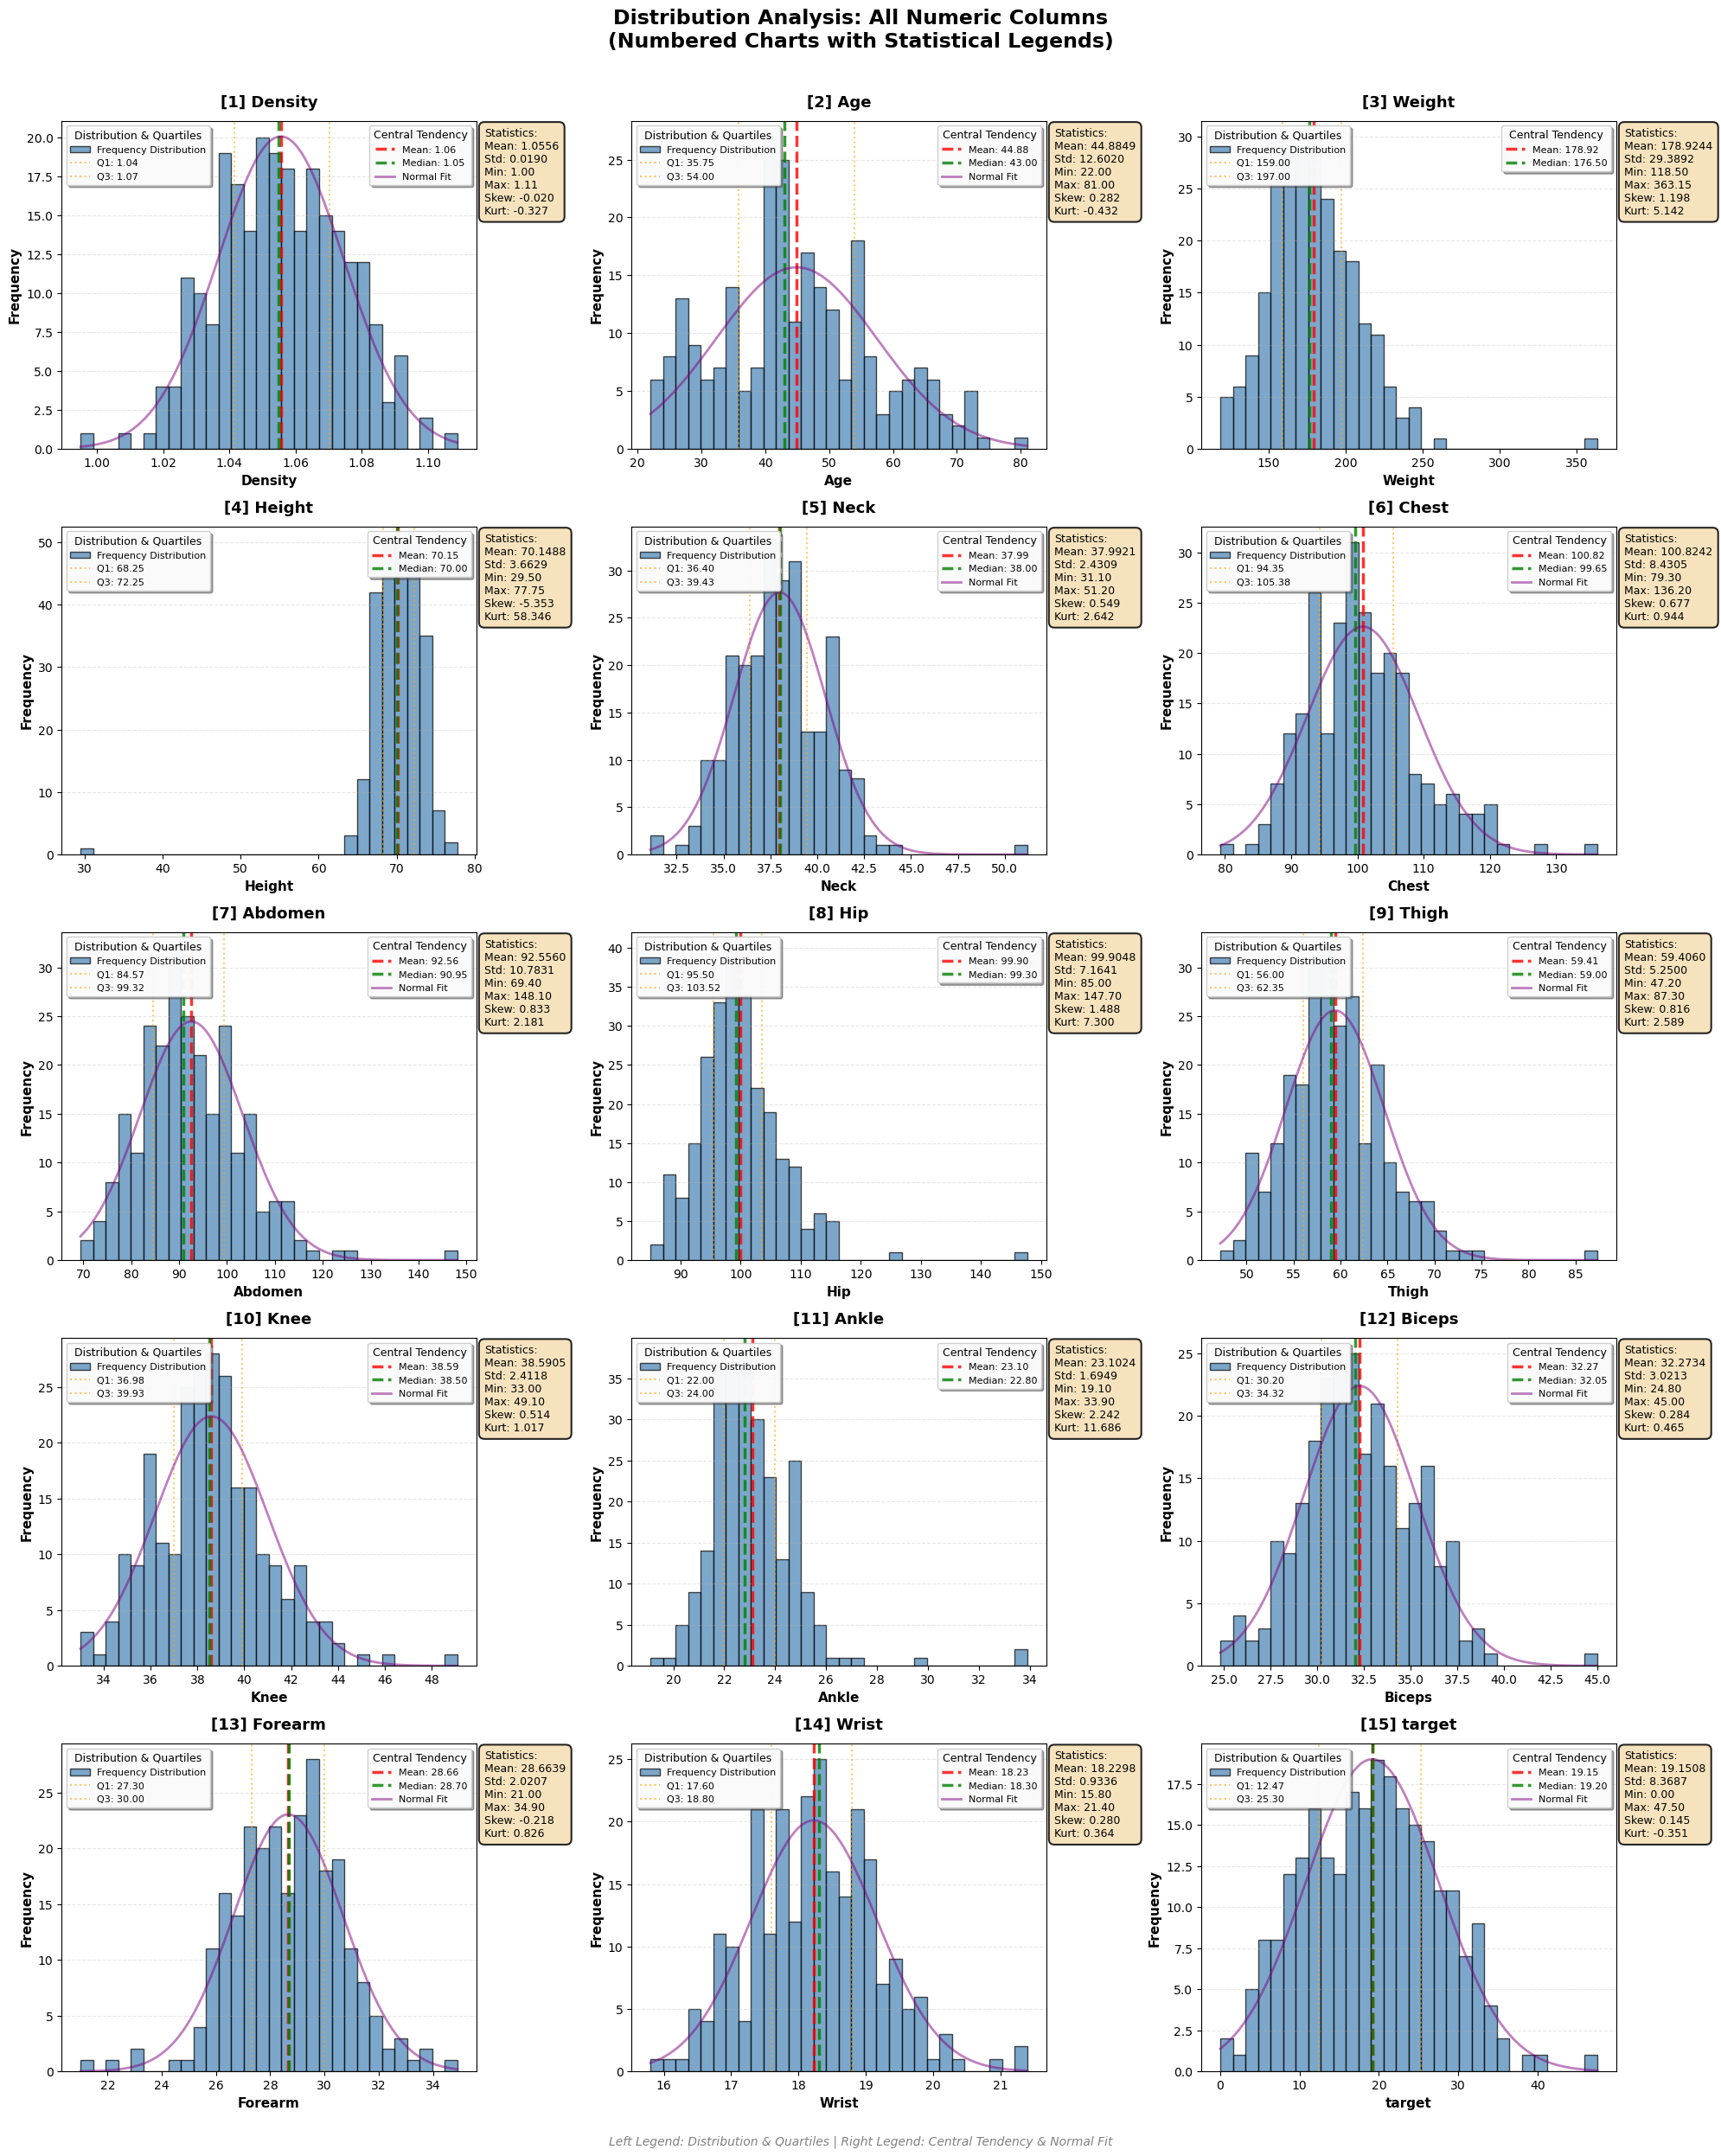


--------------------------------------------------------------------------------
DISTRIBUTION SUMMARY TABLE
--------------------------------------------------------------------------------


,Column,Mean,Std Dev,Min,Max,Skewness,Kurtosis
0,Density,1.0556,0.0190,1.00,1.11,-0.020,-0.327
1,Age,44.8849,12.6020,22.00,81.00,0.282,-0.432
2,Weight,178.9244,29.3892,118.50,363.15,1.198,5.142
3,Height,70.1488,3.6629,29.50,77.75,-5.353,58.346
4,Neck,37.9921,2.4309,31.10,51.20,0.549,2.642
5,Chest,100.8242,8.4305,79.30,136.20,0.677,0.944
6,Abdomen,92.5560,10.7831,69.40,148.10,0.833,2.181
7,Hip,99.9048,7.1641,85.00,147.70,1.488,7.300
8,Thigh,59.4060,5.2500,47.20,87.30,0.816,2.589
9,Knee,38.5905,2.4118,33.00,49.10,0.514,1.017


In [335]:
# ============================================================================
# 4. DISTRIBUTION ANALYSIS - Histograms for all numeric columns
# ============================================================================
# Purpose: Visualize distributions of all numeric features using histograms 
#          with normal distribution overlays and statistics
# Uses: basic_stats from Section 2
# Calculates: col_specs (for display formatting)
# ============================================================================
print("\n" + "=" * 80)
print("4. DISTRIBUTION ANALYSIS")
print("=" * 80)

col_specs = {
    'Mean': ('mean', '{:.4f}'),
    'Std Dev': ('std', '{:.4f}'),
    'Min': ('min', '{:.2f}'),
    'Max': ('max', '{:.2f}'),
    'Skewness': ('skewness', '{:.3f}'),
    'Kurtosis': ('kurtosis', '{:.3f}')
}
stats_labels = {'Std Dev': 'Std', 'Skewness': 'Skew', 'Kurtosis': 'Kurt'}   
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    stats = basic_stats[col]  # Use stats calculated in Section 2
    
    # Create histogram
    n, bins, patches = axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7, 
                                    color='steelblue')
    
    # Add vertical lines using stats from Section 2
    mean_line = axes[i].axvline(stats['mean'], color='red', linestyle='--', linewidth=2.5, 
                    alpha=0.8, label=f'Mean: {stats["mean"]:.2f}')
    median_line = axes[i].axvline(stats['median'], color='green', linestyle='--', linewidth=2.5, 
                    alpha=0.8, label=f'Median: {stats["median"]:.2f}')
    q25_line = axes[i].axvline(stats['q25'], color='orange', linestyle=':', linewidth=1.5, 
                    alpha=0.6, label=f'Q1: {stats["q25"]:.2f}')
    q75_line = axes[i].axvline(stats['q75'], color='orange', linestyle=':', linewidth=1.5, 
                    alpha=0.6, label=f'Q3: {stats["q75"]:.2f}')
    
    # Add normal distribution overlay using stats from Section 2
    norm_line = None
    if abs(stats['skewness']) < 1:
        x_norm = np.linspace(stats['min'], stats['max'], 100)
        y_norm = scipy.stats.norm.pdf(x_norm, stats['mean'], stats['std']) * len(data) * (bins[1] - bins[0])
        norm_line = axes[i].plot(x_norm, y_norm, 'purple', linestyle='-', linewidth=2, 
                    alpha=0.5, label='Normal Fit')[0]
    
    # Set title with number badge
    title_text = f'[{i+1}] {col}'
    axes[i].set_title(title_text, fontsize=13, fontweight='bold', pad=12)
    axes[i].set_xlabel(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # Add statistics box using stats from Section 2
    stats_text = 'Statistics:\n' + '\n'.join(
    f'{stats_labels.get(name, name)}: ' + fmt.format(stats[key])
    for name, (key, fmt) in col_specs.items())
    
    axes[i].text(1.02, 0.98, stats_text, transform=axes[i].transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                         edgecolor='black', linewidth=1.5, pad=0.5))
    
    # Create legends (same as before)
    left_handles = [
        plt.Rectangle((0,0),1,1, facecolor='steelblue', alpha=0.7, edgecolor='black'),
        q25_line,
        q75_line
    ]
    left_labels = ['Frequency Distribution', f'Q1: {stats["q25"]:.2f}', f'Q3: {stats["q75"]:.2f}']
    
    right_handles = [mean_line, median_line]
    right_labels = [f'Mean: {stats["mean"]:.2f}', f'Median: {stats["median"]:.2f}']
    
    if norm_line is not None:
        right_handles.append(norm_line)
        right_labels.append('Normal Fit')
    
    left_legend = axes[i].legend(left_handles, left_labels, 
                                loc='upper left', fontsize=8, framealpha=0.95, 
                                fancybox=True, shadow=True, title='Distribution & Quartiles',
                                title_fontsize=9)
    right_legend = axes[i].legend(right_handles, right_labels, 
                                 loc='upper right', fontsize=8, framealpha=0.95, 
                                 fancybox=True, shadow=True, title='Central Tendency',
                                 title_fontsize=9)
    axes[i].add_artist(left_legend)

# Hide extra subplots
for i in range(len(numeric_cols), len(axes)):
    axes[i].axis('off')

plt.suptitle('Distribution Analysis: All Numeric Columns\n(Numbered Charts with Statistical Legends)', 
             fontsize=17, fontweight='bold', y=0.998)
fig.text(0.5, 0.01, 
         'Left Legend: Distribution & Quartiles | Right Legend: Central Tendency & Normal Fit',
         ha='center', fontsize=10, style='italic', color='gray')
plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# Print summary table using pre-computed stats
print("\n" + "-" * 80)
print("DISTRIBUTION SUMMARY TABLE")
print("-" * 80)
summary_stats = []
# Build DataFrame using specs
summary_df = pd.DataFrame([
    {'Column': col, **{name: stats[key] for name, (key, _) in col_specs.items()}}
    for col, stats in basic_stats.items()
])
# Build format dictionary from specs
format_dict = {name: fmt for name, (_, fmt) in col_specs.items()}

# Display with formatting
display(summary_df.style.format(format_dict)
  .background_gradient(subset=['Skewness'], cmap='RdYlGn', vmin=-2, vmax=2))

**4. Distribution Analysis (Histograms)**

In this part of the analysis, I explored the distribution of each numerical feature using histograms. These visualizations help illustrate the overall shape, spread, and central tendency of the data. To make the plots more informative, I included statistical annotations such as the mean, median, quartiles, skewness, and kurtosis. This combination of visuals and metrics makes it easier to see whether a variable is normally distributed, skewed to the left or right, or exhibits heavy tails. Understanding these distributional patterns is important because they influence which statistical methods are appropriate and whether any transformations might be needed before modeling. For variables that appear roughly symmetric, I overlaid a normal distribution curve to provide a quick visual check for normality, while the skewness and kurtosis values offer a more quantitative assessment of each distribution.


5. OUTLIER DETECTION - Box Plots


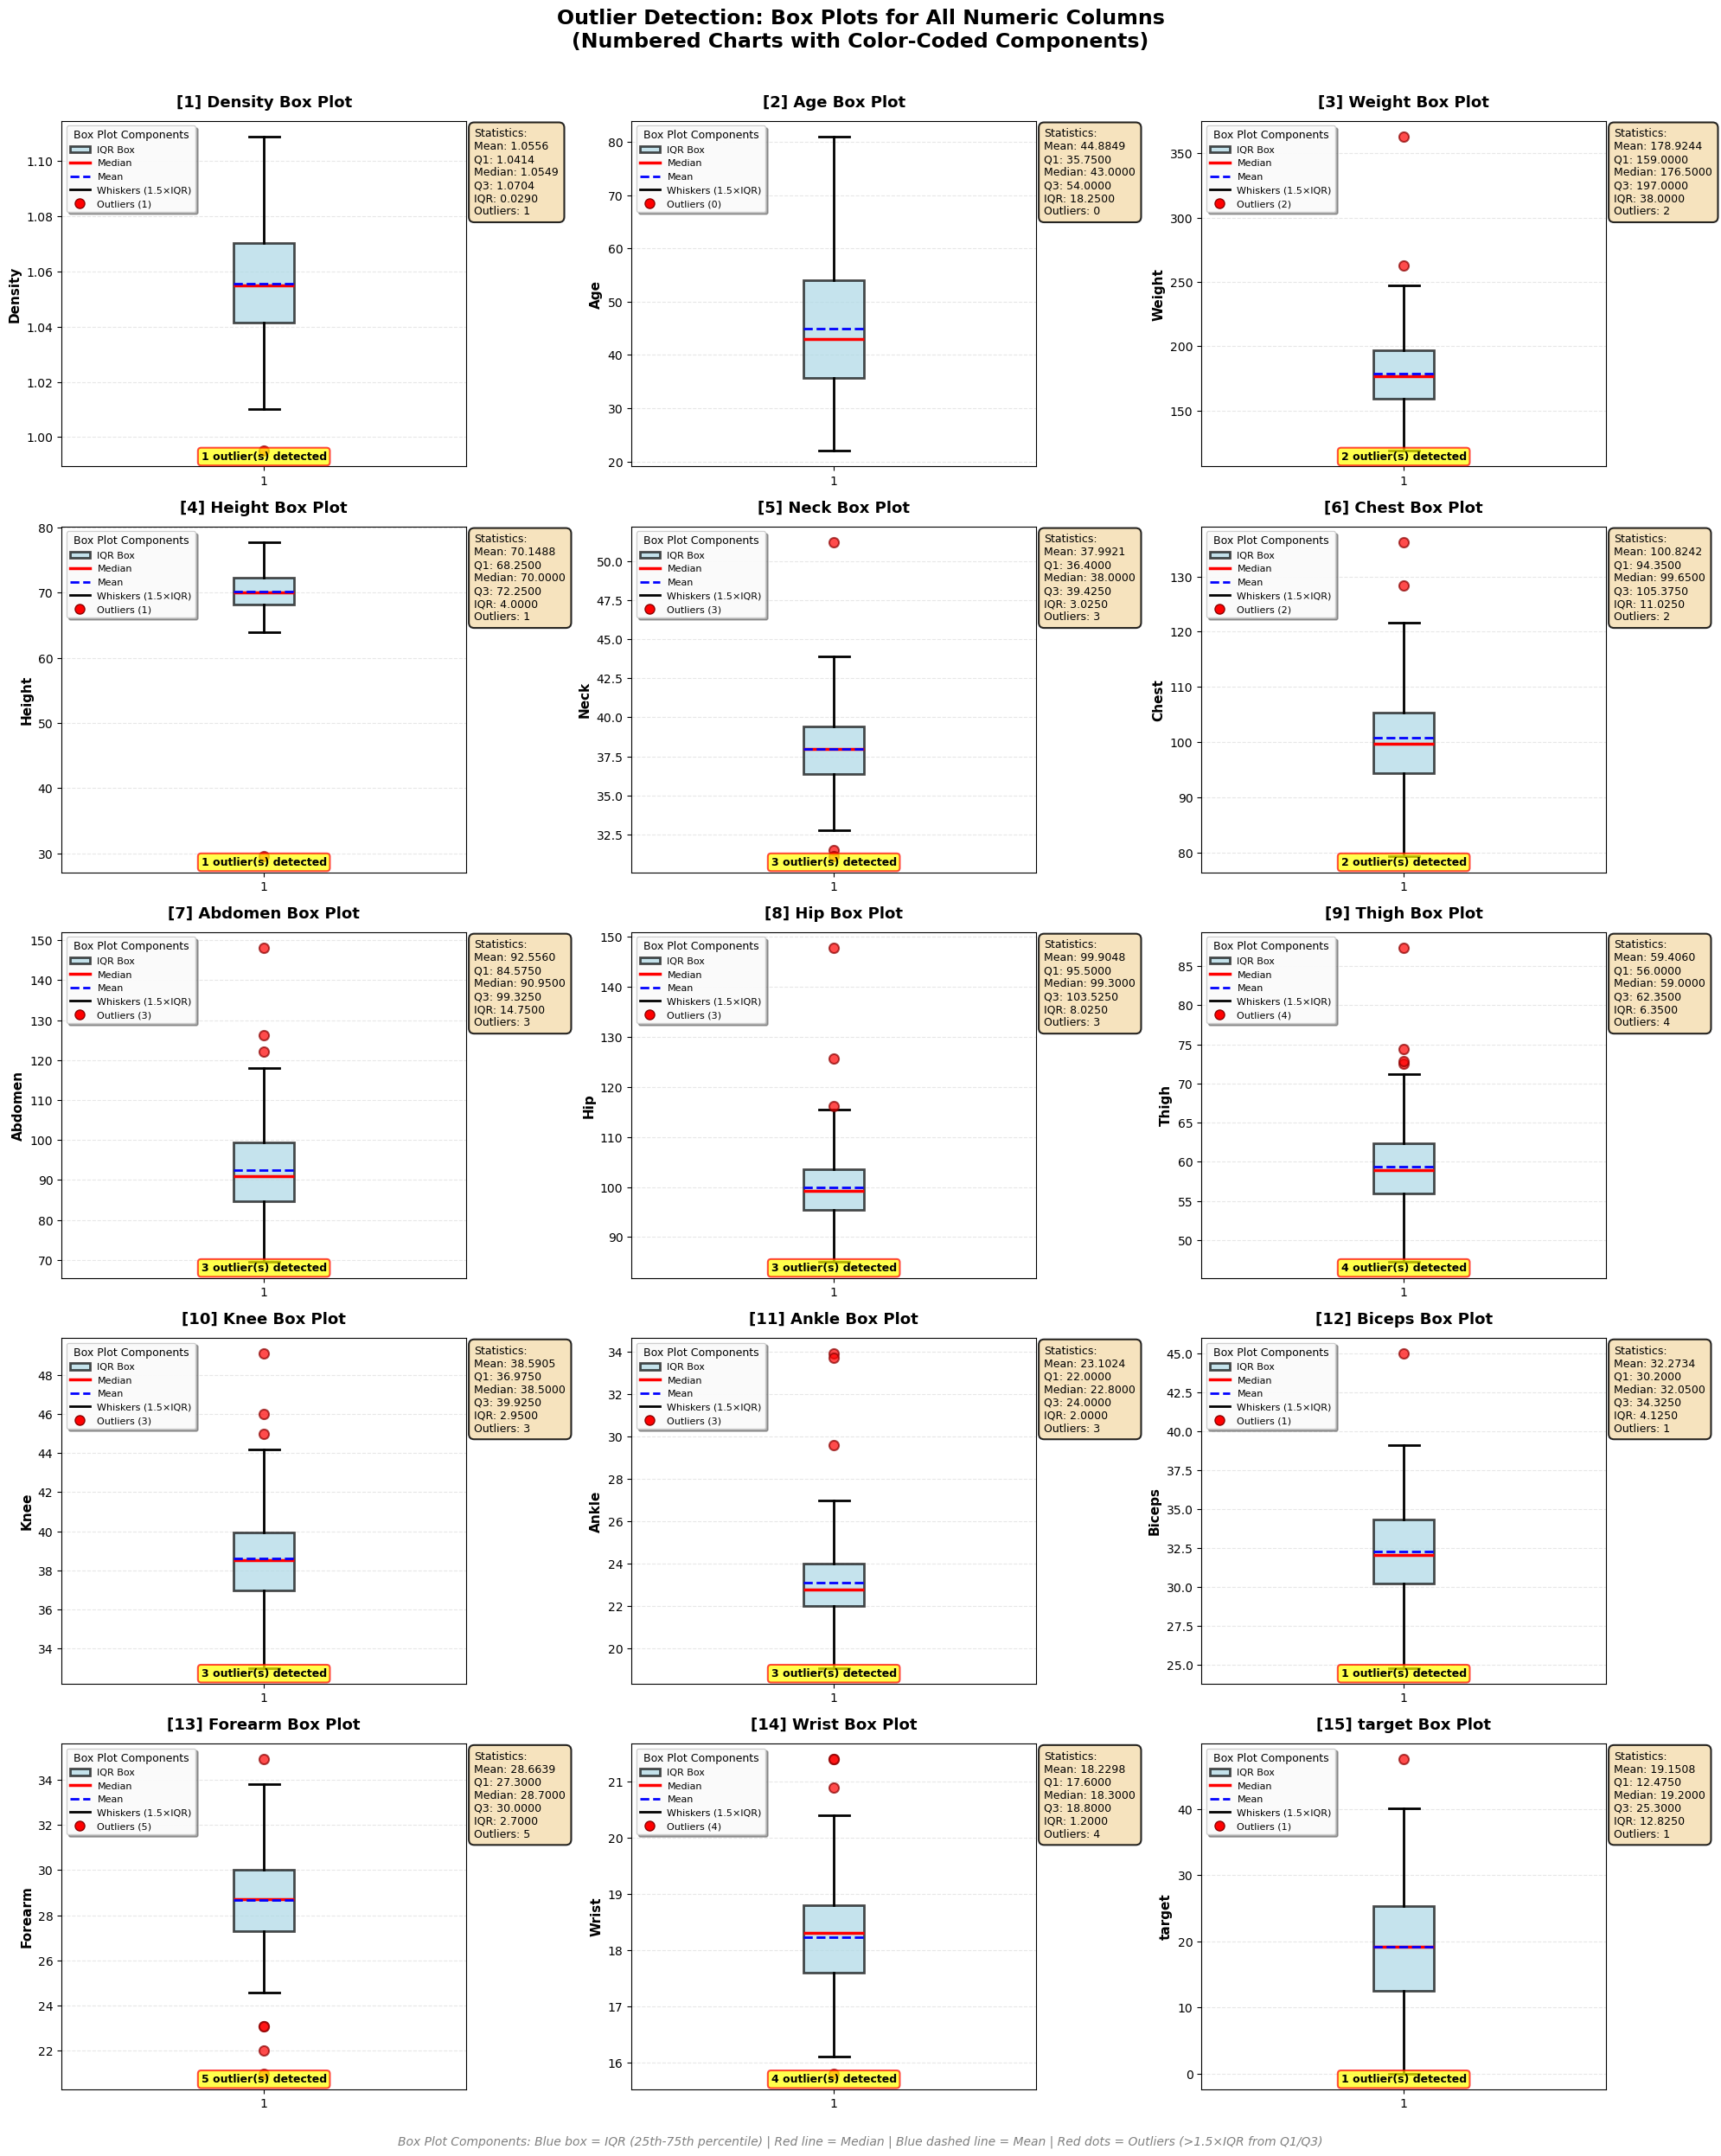


--------------------------------------------------------------------------------
OUTLIER SUMMARY TABLE
--------------------------------------------------------------------------------


,Column,Q1,Median,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
0,Density,1.0414,1.0549,1.0704,0.0290,0.9979,1.1139,1,0.40%
1,Age,35.7500,43.0000,54.0000,18.2500,8.3750,81.3750,0,0.00%
2,Weight,159.0000,176.5000,197.0000,38.0000,102.0000,254.0000,2,0.79%
3,Height,68.2500,70.0000,72.2500,4.0000,62.2500,78.2500,1,0.40%
4,Neck,36.4000,38.0000,39.4250,3.0250,31.8625,43.9625,3,1.19%
5,Chest,94.3500,99.6500,105.3750,11.0250,77.8125,121.9125,2,0.79%
6,Abdomen,84.5750,90.9500,99.3250,14.7500,62.4500,121.4500,3,1.19%
7,Hip,95.5000,99.3000,103.5250,8.0250,83.4625,115.5625,3,1.19%
8,Thigh,56.0000,59.0000,62.3500,6.3500,46.4750,71.8750,4,1.59%
9,Knee,36.9750,38.5000,39.9250,2.9500,32.5500,44.3500,3,1.19%


In [336]:
# ============================================================================
# 5. BOX PLOTS - To identify outliers
# ============================================================================
# Purpose: Identify outliers using box plots and IQR method, calculate outlier 
#          statistics for all numeric columns
# Uses: basic_stats from Section 2
# Calculates: outlier_col_specs, outlier_stats
# ============================================================================

print("\n" + "=" * 80)
print("5. OUTLIER DETECTION - Box Plots")
print("=" * 80)

# Calculate outlier statistics (first time - will be reused if needed)
outlier_col_specs = {
    'Q1': ('outlier', 'q1', '{:.4f}'),
    'Median': ('basic', 'median', '{:.4f}'),
    'Q3': ('outlier', 'q3', '{:.4f}'),
    'IQR': ('outlier', 'iqr', '{:.4f}'),
    'Lower Fence': ('outlier', 'lower_fence', '{:.4f}'),
    'Upper Fence': ('outlier', 'upper_fence', '{:.4f}'),
    'Outlier Count': ('outlier', 'outlier_count', '{:.0f}'),
    'Outlier %': ('outlier', 'outlier_pct', '{:.2f}%')
}
outlier_stats = {}
for col in numeric_cols:
    stats = basic_stats[col]  # Use stats from Section 2
    outlier_stats[col] = {
        'q1': stats['q25'],
        'q3': stats['q75'],
        'iqr': stats['iqr'],
        'lower_fence': stats['q25'] - 1.5 * stats['iqr'],
        'upper_fence': stats['q75'] + 1.5 * stats['iqr']
    }
    # Identify outliers
    outliers = df[col][(df[col] < outlier_stats[col]['lower_fence']) | 
                        (df[col] > outlier_stats[col]['upper_fence'])]
    outlier_stats[col]['outlier_count'] = len(outliers)
    outlier_stats[col]['outlier_pct'] = (len(outliers) / len(df[col].dropna()) * 100)

# Create box plots using stats from Section 2 and outlier_stats calculated above
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    stats = basic_stats[col]  # From Section 2
    outlier_info = outlier_stats[col]  # Calculated above
    
    # Create box plot
    bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                         showmeans=True, meanline=True,
                         boxprops=dict(linewidth=2, color='black'),
                         whiskerprops=dict(linewidth=2, color='black'),
                         capprops=dict(linewidth=2, color='black'),
                         medianprops=dict(linewidth=2.5, color='red'),
                         meanprops=dict(linewidth=2, color='blue', linestyle='--'),
                         flierprops=dict(marker='o', markerfacecolor='red', 
                                        markeredgecolor='darkred', markersize=8,
                                        alpha=0.7, markeredgewidth=1.5))
    
    # Color the box
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    # Set title with number badge
    title_text = f'[{i+1}] {col} Box Plot'
    axes[i].set_title(title_text, fontsize=13, fontweight='bold', pad=12)
    axes[i].set_ylabel(col, fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # Add statistics box using pre-computed values
    stats_text = (f'Statistics:\n'
                  f'Mean: {stats["mean"]:.4f}\n'
                  f'Q1: {outlier_info["q1"]:.4f}\n'
                  f'Median: {stats["median"]:.4f}\n'
                  f'Q3: {outlier_info["q3"]:.4f}\n'
                  f'IQR: {outlier_info["iqr"]:.4f}\n'
                  f'Outliers: {outlier_info["outlier_count"]}')
    
    axes[i].text(1.02, 0.98, stats_text, transform=axes[i].transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                         edgecolor='black', linewidth=1.5, pad=0.5))
    
    # Create legend elements
    legend_elements = [
        Rectangle((0,0),1,1, facecolor='lightblue', alpha=0.7, edgecolor='black', linewidth=2, label='IQR Box'),
        Line2D([0], [0], color='red', linewidth=2.5, label='Median'),
        Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label='Mean'),
        Line2D([0], [0], color='black', linewidth=2, label='Whiskers (1.5×IQR)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
               markeredgecolor='darkred', markersize=8, linestyle='None', 
               label=f'Outliers ({outlier_info["outlier_count"]})')
    ]
    
    axes[i].legend(handles=legend_elements, loc='upper left', fontsize=8, 
                  framealpha=0.95, fancybox=True, shadow=True, title='Box Plot Components',
                  title_fontsize=9)
    
    # Add annotation for outlier count if significant
    if outlier_info['outlier_count'] > 0:
        axes[i].text(0.5, 0.02, f'{outlier_info["outlier_count"]} outlier(s) detected', 
                    transform=axes[i].transAxes,
                    fontsize=9, ha='center', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7,
                             edgecolor='red', linewidth=1.5))

# Hide extra subplots
for i in range(len(numeric_cols), len(axes)):
    axes[i].axis('off')

plt.suptitle('Outlier Detection: Box Plots for All Numeric Columns\n(Numbered Charts with Color-Coded Components)', 
             fontsize=17, fontweight='bold', y=0.998)
fig.text(0.5, 0.01, 
         'Box Plot Components: Blue box = IQR (25th-75th percentile) | Red line = Median | Blue dashed line = Mean | Red dots = Outliers (>1.5×IQR from Q1/Q3)',
         ha='center', fontsize=10, style='italic', color='gray')
plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# Print outlier summary table using pre-computed stats
print("\n" + "-" * 80)
print("OUTLIER SUMMARY TABLE")
print("-" * 80)
outlier_summary = []
outlier_df = pd.DataFrame([
    {
        'Column': col,
        **{name: (basic_stats[col] if src == 'basic' else outlier_stats[col])[key]
           for name, (src, key, _) in outlier_col_specs.items()}
    }
    for col in numeric_cols
])

format_dict = {name: fmt for name, (_, _, fmt) in outlier_col_specs.items()}
display(outlier_df.style.format(format_dict)
  .background_gradient(subset=['Outlier Count'], cmap='Reds', vmin=0))

**5. Outlier Detection (Box Plots)**
This section utilizes box plots to systematically detect potential outliers across all numerical features using the Interquartile Range (IQR) method. Box plots visually summarize each variable’s distribution by displaying the median, quartiles, and overall spread, while marking observations that lie beyond 1.5 × IQR from the first or third quartile as outliers.

The analysis highlights which features contain extreme values that may stem from measurement errors, data-entry issues, or genuinely rare events. Identifying these outliers is essential, as they can disproportionately influence model performance—particularly in regression-based models that are sensitive to extreme observations.

A summary table accompanies this section, detailing the count and proportion of outliers for each feature. This helps prioritize variables that may require additional preprocessing steps such as winsorization, data transformation, or case-by-case review to ensure model robustness.


In [337]:
# ============================================================================
# 6a. SCATTER PLOTS - Key features vs Target
# ============================================================================
# Purpose: Visualize relationships between key features and target variable 
#          using scatter plots with regression lines and quartile color coding
# Uses: None (first calculation)
# Calculates: target_quartile, quartile_colors, regression_coeffs, 
#             plot_abdomen_vs_bodyfat() function
# ============================================================================

print("\n" + "=" * 80)
print("6. FEATURE-TARGET RELATIONSHIPS")
print("=" * 80)

# Define key features
key_features = ['Age', 'Weight', 'Height', 'Abdomen', 'Chest', 'Hip', 'Thigh']

# Create target quartiles (first time - will be reused in Section 9)
df['target_quartile'] = pd.qcut(df['target'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
quartile_colors = {'Q1 (Low)': 'green', 'Q2': 'yellow', 'Q3': 'orange', 'Q4 (High)': 'red'}

# Calculate regression coefficients for key features (first time - will be reused in Section 6b and 10)
regression_coeffs = {}
for feat in key_features:
    z = np.polyfit(df[feat], df['target'], 1)
    corr = df[feat].corr(df['target'])
    regression_coeffs[feat] = {
        'slope': z[0],
        'intercept': z[1],
        'correlation': corr,
        'r_squared': corr**2,
        'poly_func': np.poly1d(z)
    }


6. FEATURE-TARGET RELATIONSHIPS


In [338]:
# ============================================================================
# Abdomen vs Body Fat plot 
# Adaptive: works in grid (ax provided) or standalone (ax=None)
# ============================================================================
def plot_abdomen_vs_bodyfat(ax=None, figsize=(12, 8), title_suffix="", index_in_grid=None):
    """
    Plot Abdomen vs Body Fat scatter plot with regression line.
    
    This function creates a scatter plot showing the relationship between
    abdominal circumference and body fat percentage. The plot includes:
    - Color coding by target quartiles (Q1=green, Q2=yellow, Q3=orange, Q4=red)
    - Linear regression line with correlation coefficient
    - Statistics box with correlation, R², slope, and intercept
    - Adaptive styling for grid plots vs standalone plots
    
    The function automatically adapts its styling based on whether it's used
    in a grid (ax provided) or standalone (ax=None) context.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes, optional
        Axis to plot on. If None, creates a new figure (standalone mode).
        If provided, plots on the given axis (grid mode).
    figsize : tuple, default (12, 8)
        Figure size for standalone plots. Ignored if ax is provided.
    title_suffix : str, default ""
        Additional text to append to the title (e.g., "\n(Strongest Correlation)").
    index_in_grid : int, optional
        Index number for grid plots (e.g., 4 for "[4] Abdomen vs Body Fat %").
        Used only in grid mode. If None in grid mode, defaults to 4.
    
    Returns:
    --------
    matplotlib.axes.Axes
        The axes object with the plot.
    
    Uses:
    -----
    - target_quartile : Created in Section 6a
    - quartile_colors : Created in Section 6a
    - regression_coeffs['Abdomen'] : Calculated in Section 6a
    
    Notes:
    ------
    - In standalone mode: larger fonts (16-18), detailed labels, stats box top-left
    - In grid mode: smaller fonts (11-13), concise labels, stats box top-right
    - The function is defined in Section 6a and reused in "3 interesting charts"

    """
    # Determine if this is a grid plot or standalone
    is_standalone = (ax is None)
    
    if is_standalone:
        fig, ax = plt.subplots(figsize=figsize)
    
    abdomen_coeffs = regression_coeffs['Abdomen']
    
    # Adjust styling based on context
    if is_standalone:
        # Standalone plot: larger fonts, more detailed labels
        marker_size = 120
        line_width = 4
        title_fontsize = 18
        label_fontsize = 16
        stats_fontsize = 12
        legend_fontsize = 12
        legend_title_fontsize = 13
        xlabel_text = 'Abdomen Circumference (cm)'
        ylabel_text = 'Body Fat %'
        title_text = f'Abdomen Circumference vs Body Fat Percentage{title_suffix}'
        stats_position = (0.02, 0.98)  # Top left
        stats_ha = 'left'
        legend_loc = 'lower right'
        edge_linewidth = 0.8
    else:
        # Grid plot: smaller fonts, consistent with other features
        marker_size = 80
        line_width = 3
        title_fontsize = 13
        label_fontsize = 11
        stats_fontsize = 9
        legend_fontsize = 8
        legend_title_fontsize = 9
        xlabel_text = 'Abdomen'
        ylabel_text = 'Body Fat % (target)'
        title_text = f'[{index_in_grid if index_in_grid is not None else 4}] Abdomen vs Body Fat %'
        stats_position = (0.98, 0.98)  # Top right
        stats_ha = 'right'
        legend_loc = 'upper left'
        edge_linewidth = 0.5
    
    # Color code by target quartiles
    for quartile, color in quartile_colors.items():
        mask = df['target_quartile'] == quartile
        ax.scatter(df.loc[mask, 'Abdomen'], df.loc[mask, 'target'], 
                   c=color, label=quartile, alpha=0.7, s=marker_size, 
                   edgecolors='black', linewidth=edge_linewidth)
    
    # Add regression line
    ax.plot(df['Abdomen'], abdomen_coeffs['poly_func'](df['Abdomen']), 
            "darkblue", linestyle='--', linewidth=line_width, alpha=0.9, 
            label=f'Linear Fit (r={abdomen_coeffs["correlation"]:.3f})', zorder=1)
    
    # Set labels and title
    ax.set_xlabel(xlabel_text, fontsize=label_fontsize, fontweight='bold')
    ax.set_ylabel(ylabel_text, fontsize=label_fontsize, fontweight='bold')
    ax.set_title(title_text, fontsize=title_fontsize, fontweight='bold', 
                 pad=20 if is_standalone else 12)
    ax.grid(True, alpha=0.3, linestyle='--', zorder=0)
    
    # Add statistics box
    if is_standalone:
        # Standalone: simpler stats box
        stats_text = (f'Correlation: {abdomen_coeffs["correlation"]:.4f}\n'
                      f'R²: {abdomen_coeffs["r_squared"]:.4f}\n'
                      f'Slope: {abdomen_coeffs["slope"]:.4f}\n'
                      f'Intercept: {abdomen_coeffs["intercept"]:.2f}')
        edge_color = 'green'
        linewidth = 2.5
        pad = 0.8
    else:
        # Grid: detailed stats box matching other features
        strength = "Strong" if abs(abdomen_coeffs['correlation']) > 0.7 else "Moderate" if abs(abdomen_coeffs['correlation']) > 0.4 else "Weak"
        stats_text = (f'Statistics:\n'
                      f'Correlation: {abdomen_coeffs["correlation"]:.4f}\n'
                      f'R²: {abdomen_coeffs["r_squared"]:.4f}\n'
                      f'Slope: {abdomen_coeffs["slope"]:.4f}\n'
                      f'Intercept: {abdomen_coeffs["intercept"]:.2f}\n'
                      f'Strength: {strength}')
        strength_color = 'green' if abs(abdomen_coeffs['correlation']) > 0.7 else 'orange' if abs(abdomen_coeffs['correlation']) > 0.4 else 'red'
        edge_color = strength_color
        linewidth = 2
        pad = 0.5
    
    ax.text(stats_position[0], stats_position[1], stats_text, transform=ax.transAxes,
            fontsize=stats_fontsize, verticalalignment='top', horizontalalignment=stats_ha,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9 if is_standalone else 0.85, 
                     edgecolor=edge_color, linewidth=linewidth, pad=pad))
    
    # Add legend
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, framealpha=0.95, 
              fancybox=True, shadow=True, title='Body Fat Quartiles',
              title_fontsize=legend_title_fontsize, ncol=1)
    
    if is_standalone:
        plt.tight_layout()
        plt.show()
    return ax



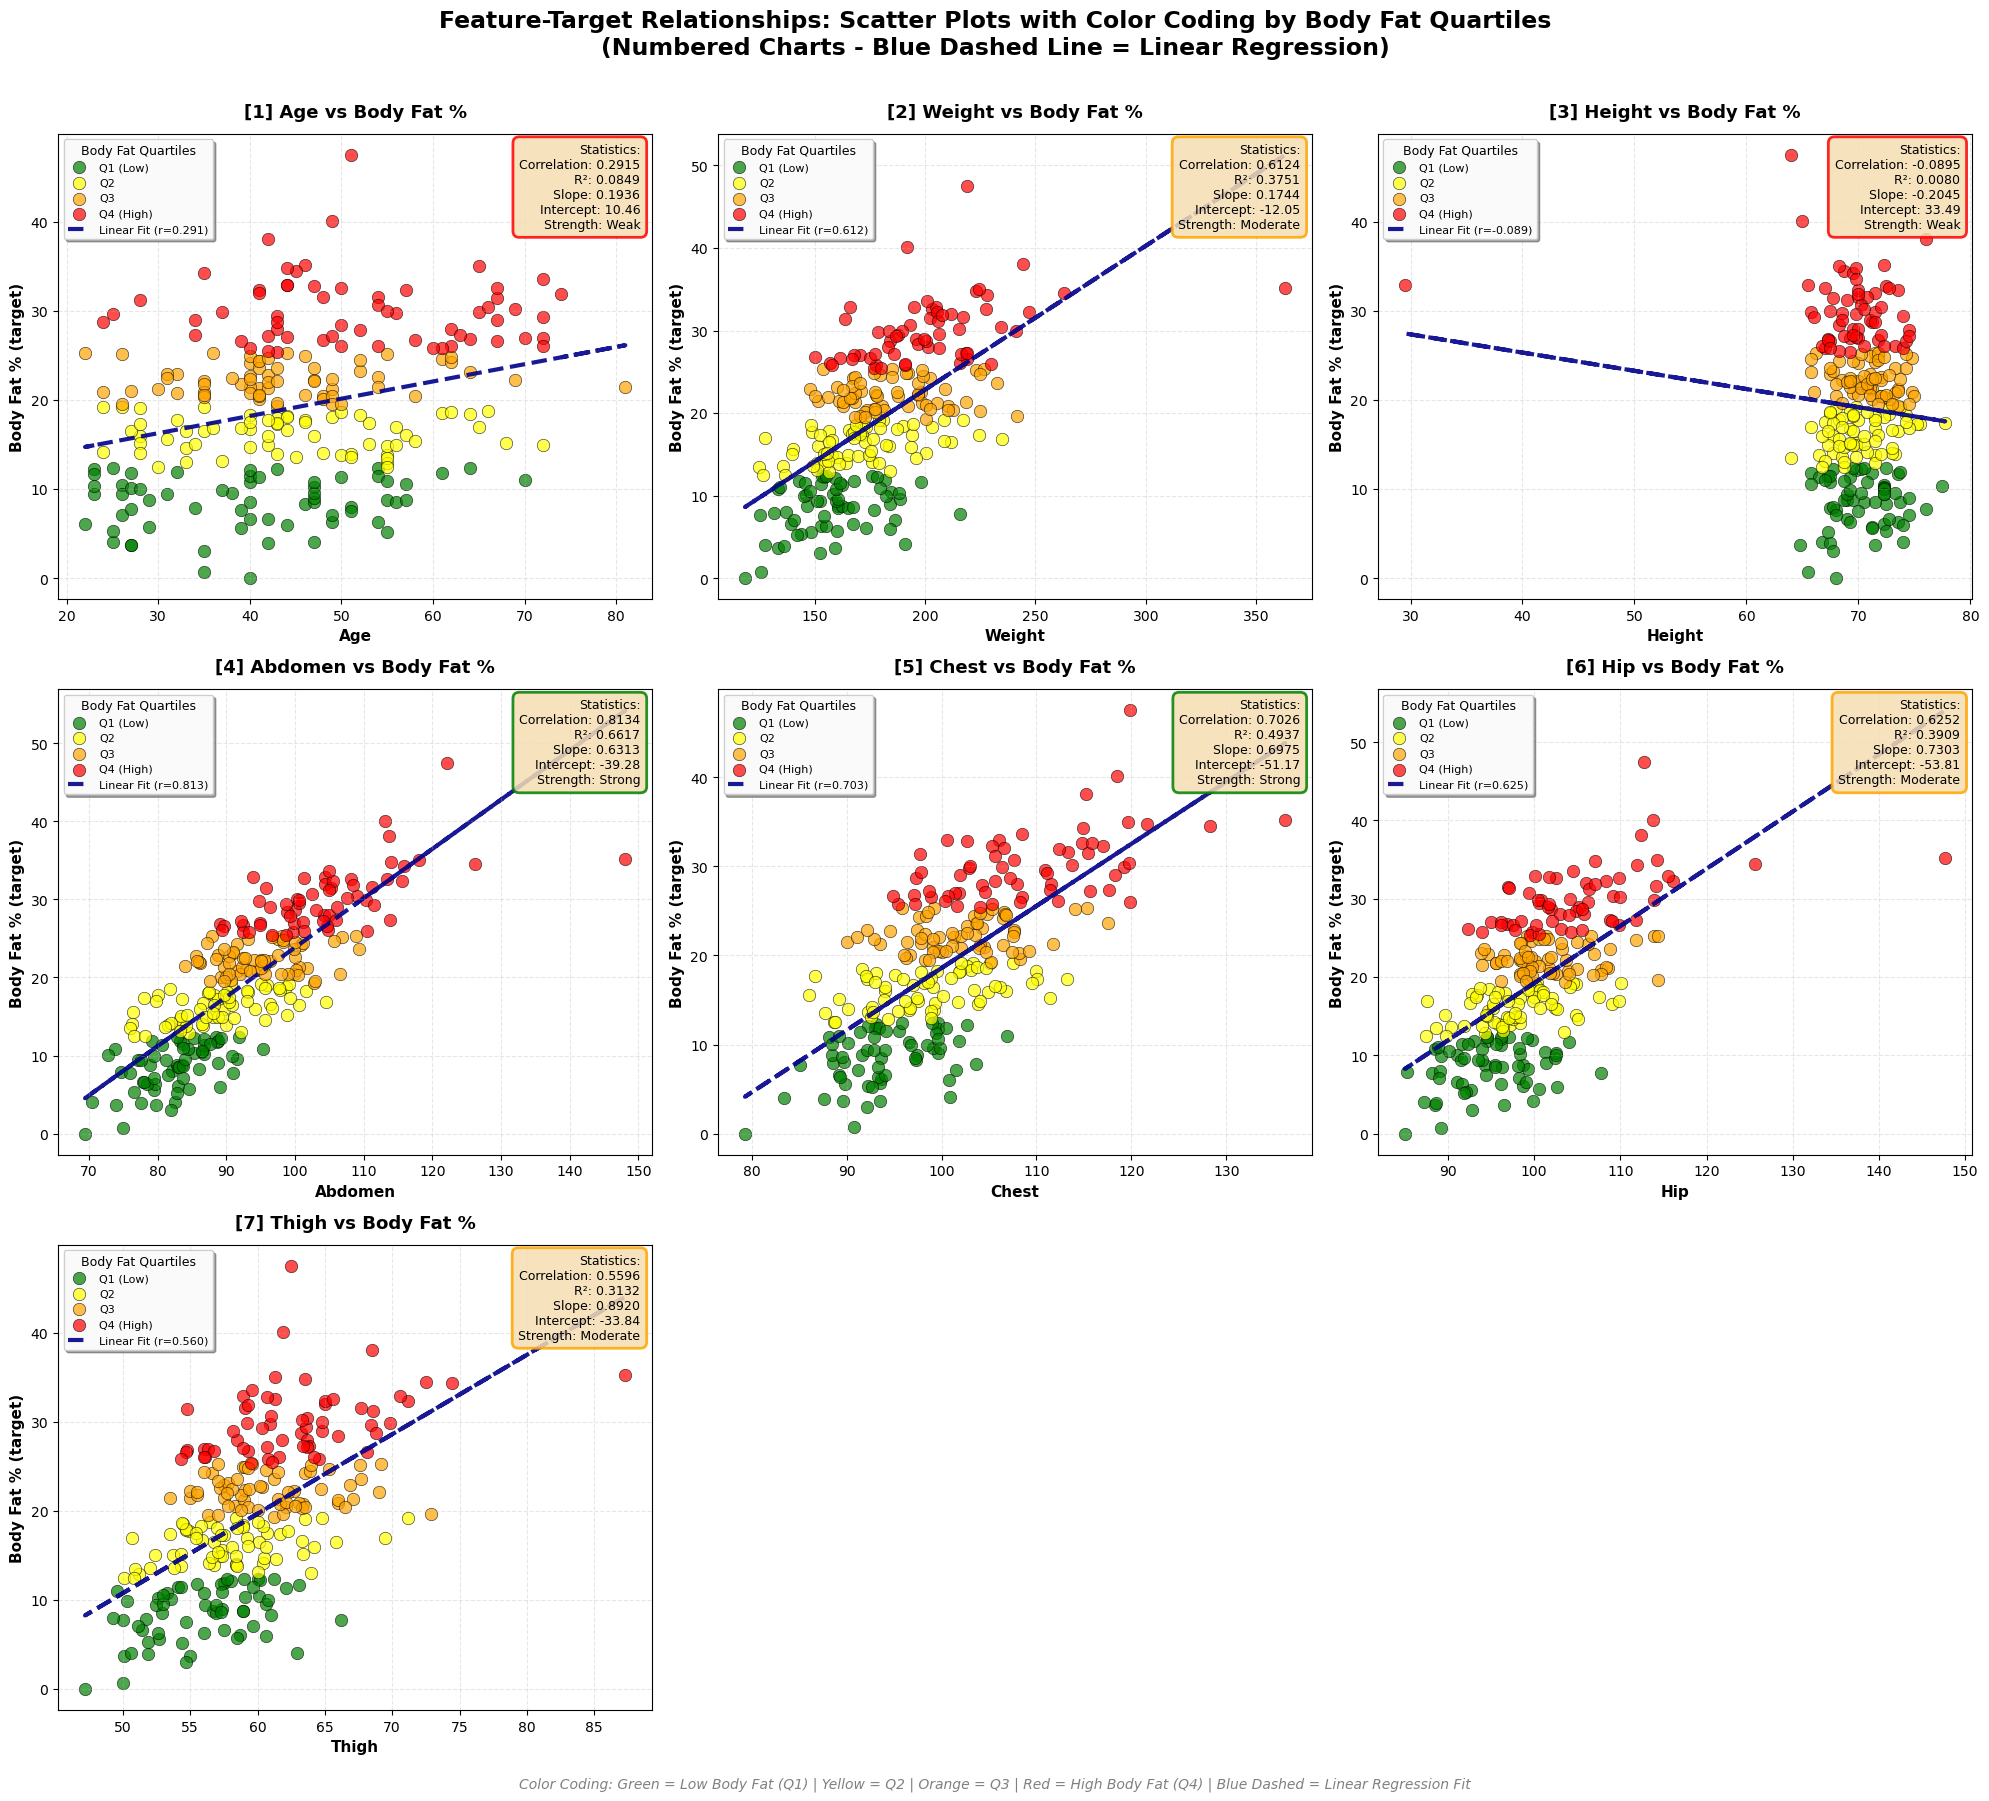


--------------------------------------------------------------------------------
CORRELATION SUMMARY TABLE
--------------------------------------------------------------------------------


,Feature,Correlation,|Correlation|,R²,Slope,Strength
3,Abdomen,0.8134,0.8134,0.6617,0.6313,Strong
4,Chest,0.7026,0.7026,0.4937,0.6975,Strong
5,Hip,0.6252,0.6252,0.3909,0.7303,Moderate
1,Weight,0.6124,0.6124,0.3751,0.1744,Moderate
6,Thigh,0.5596,0.5596,0.3132,0.8920,Moderate
0,Age,0.2915,0.2915,0.0849,0.1936,Weak
2,Height,-0.0895,0.0895,0.0080,-0.2045,Weak


In [339]:
# Create scatter plots for all key features
n_feat = len(key_features)
n_cols_feat = 3
n_rows_feat = (n_feat + n_cols_feat - 1) // n_cols_feat

fig, axes = plt.subplots(n_rows_feat, n_cols_feat, figsize=(20, 6*n_rows_feat))
axes = axes.flatten() if n_rows_feat > 1 else [axes] if n_cols_feat == 1 else axes.flatten()

for i, feat in enumerate(key_features):
    reg_coeffs = regression_coeffs[feat]  # Use coefficients calculated above
    
    # Use function for Abdomen, inline code for other features
    if feat == 'Abdomen':
        # Use the reusable function for Abdomen in the grid
        plot_abdomen_vs_bodyfat(ax=axes[i], index_in_grid=i+1)
    else:
        # Inline code for other features (to maintain consistency)
        # Color code by target quartiles (calculated above)
        for quartile, color in quartile_colors.items():
            mask = df['target_quartile'] == quartile
            axes[i].scatter(df.loc[mask, feat], df.loc[mask, 'target'], 
                           c=color, label=quartile, alpha=0.7, s=80, 
                           edgecolors='black', linewidth=0.5)
        
        # Add regression line using coefficients calculated above
        axes[i].plot(df[feat], reg_coeffs['poly_func'](df[feat]), "darkblue", linestyle='--', 
                    linewidth=3, alpha=0.9, label=f'Linear Fit (r={reg_coeffs["correlation"]:.3f})')
        
        # Set title with number badge
        title_text = f'[{i+1}] {feat} vs Body Fat %'
        axes[i].set_title(title_text, fontsize=13, fontweight='bold', pad=12)
        axes[i].set_xlabel(feat, fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Body Fat % (target)', fontsize=11, fontweight='bold')
        axes[i].grid(True, alpha=0.3, linestyle='--')
        
        # Add statistics box (top right)
        strength = "Strong" if abs(reg_coeffs['correlation']) > 0.7 else "Moderate" if abs(reg_coeffs['correlation']) > 0.4 else "Weak"
        stats_text = (f'Statistics:\n'
                      f'Correlation: {reg_coeffs["correlation"]:.4f}\n'
                      f'R²: {reg_coeffs["r_squared"]:.4f}\n'
                      f'Slope: {reg_coeffs["slope"]:.4f}\n'
                      f'Intercept: {reg_coeffs["intercept"]:.2f}\n'
                      f'Strength: {strength}')
        
        strength_color = 'green' if abs(reg_coeffs['correlation']) > 0.7 else 'orange' if abs(reg_coeffs['correlation']) > 0.4 else 'red'
        
        axes[i].text(0.98, 0.98, stats_text, transform=axes[i].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                             edgecolor=strength_color, linewidth=2, pad=0.5))
        
        # Add legend (left side)
        axes[i].legend(loc='upper left', fontsize=8, framealpha=0.95, 
                      fancybox=True, shadow=True, title='Body Fat Quartiles',
                      title_fontsize=9, ncol=1)

for i in range(n_feat, len(axes)):
    axes[i].axis('off')

# Add overall title
plt.suptitle('Feature-Target Relationships: Scatter Plots with Color Coding by Body Fat Quartiles\n(Numbered Charts - Blue Dashed Line = Linear Regression)', 
             fontsize=17, fontweight='bold', y=0.998)

# Add footer explanation
fig.text(0.5, 0.01, 
         'Color Coding: Green = Low Body Fat (Q1) | Yellow = Q2 | Orange = Q3 | Red = High Body Fat (Q4) | Blue Dashed = Linear Regression Fit',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# Print correlation summary table using pre-computed values
print("\n" + "-" * 80)
print("CORRELATION SUMMARY TABLE")
print("-" * 80)
corr_summary = []
for feat in key_features:
    reg_coeffs = regression_coeffs[feat]
    corr_summary.append({
        'Feature': feat,
        'Correlation': reg_coeffs['correlation'],
        '|Correlation|': abs(reg_coeffs['correlation']),
        'R²': reg_coeffs['r_squared'],
        'Slope': reg_coeffs['slope'],
        'Strength': 'Strong' if abs(reg_coeffs['correlation']) > 0.7 else 'Moderate' if abs(reg_coeffs['correlation']) > 0.4 else 'Weak'
    })

corr_df = pd.DataFrame(corr_summary).sort_values('|Correlation|', ascending=False)
display(corr_df.style.format({
    'Correlation': '{:.4f}',
    '|Correlation|': '{:.4f}',
    'R²': '{:.4f}',
    'Slope': '{:.4f}'
}).background_gradient(subset=['Correlation', '|Correlation|'], cmap='RdYlGn_r', vmin=-1, vmax=1))


FEATURE-TARGET RELATIONSHIPS (Color by Age)


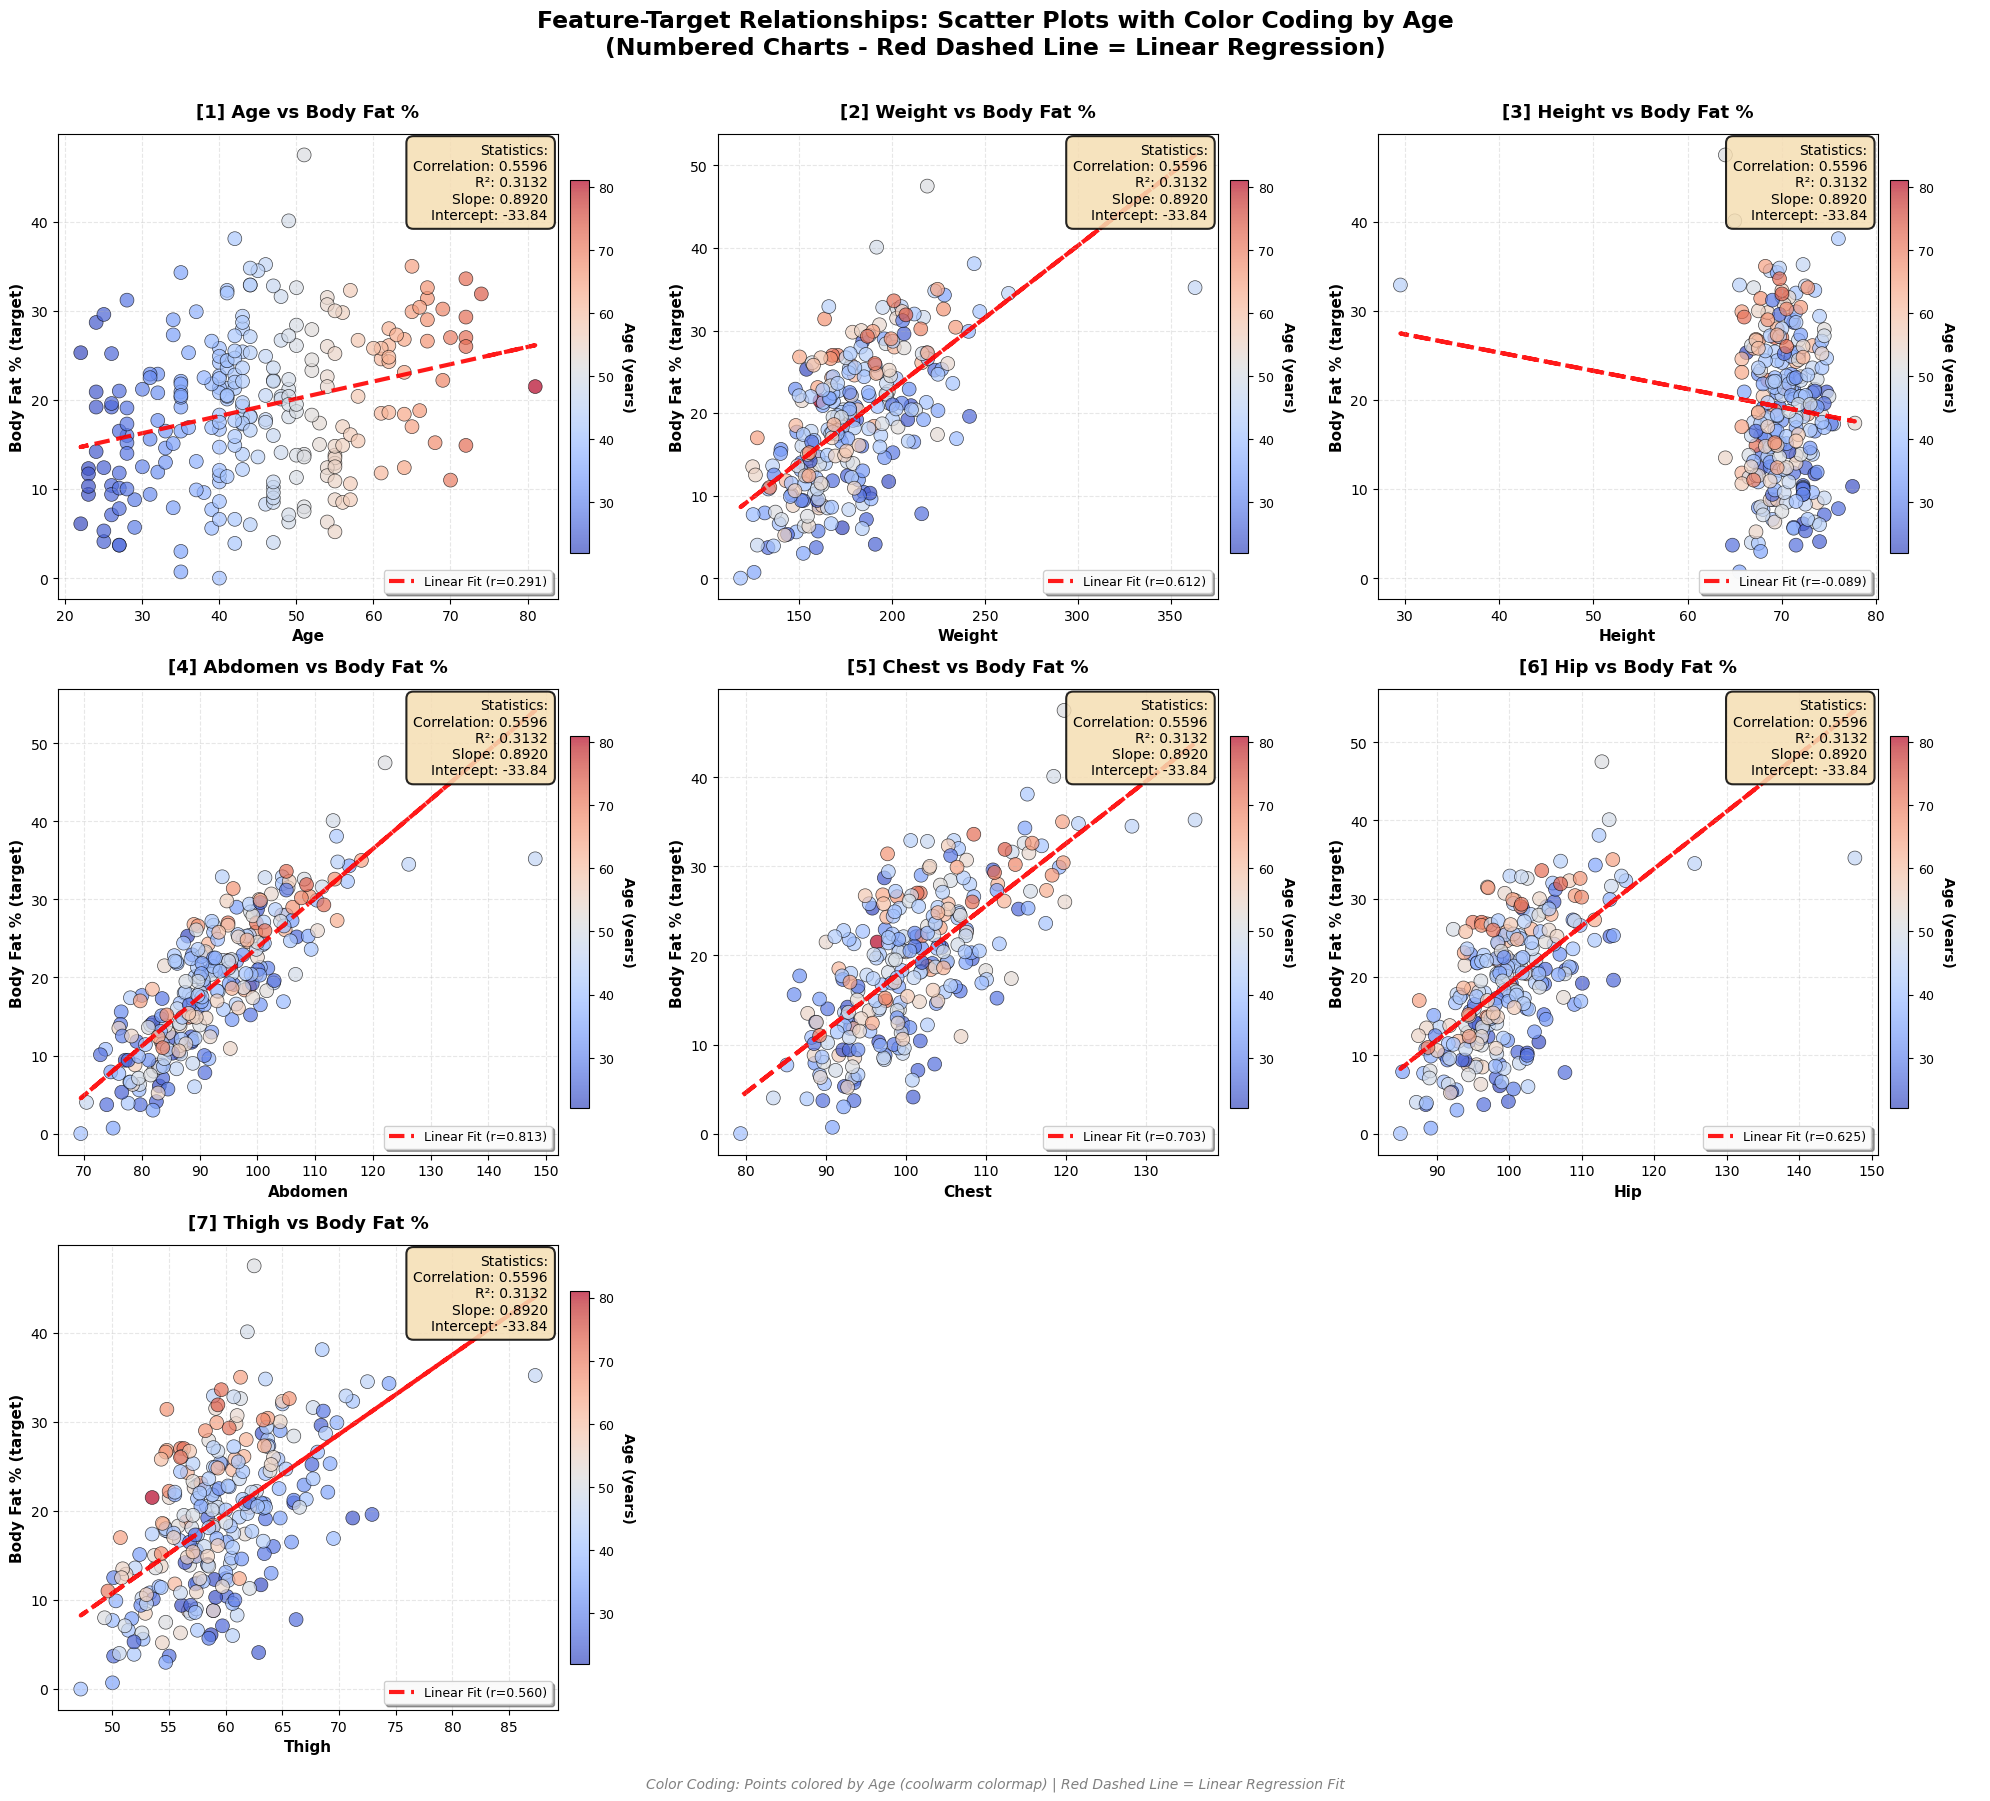


--------------------------------------------------------------------------------
CORRELATION SUMMARY TABLE
--------------------------------------------------------------------------------


,Feature,Correlation,|Correlation|,R²,Slope
3,Abdomen,0.8134,0.8134,0.6617,0.6313
4,Chest,0.7026,0.7026,0.4937,0.6975
5,Hip,0.6252,0.6252,0.3909,0.7303
1,Weight,0.6124,0.6124,0.3751,0.1744
6,Thigh,0.5596,0.5596,0.3132,0.8920
0,Age,0.2915,0.2915,0.0849,0.1936
2,Height,-0.0895,0.0895,0.0080,-0.2045


In [340]:
# ============================================================================
# 6b. SCATTER PLOTS - FEATURE-TARGET RELATIONSHIPS (Color by Age)
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE-TARGET RELATIONSHIPS (Color by Age)")
print("=" * 80)

# Use regression_coeffs calculated in Section 6a
fig, axes = plt.subplots(n_rows_feat, n_cols_feat, figsize=(20, 6*n_rows_feat))
axes = axes.flatten() if n_rows_feat > 1 else [axes] if n_cols_feat == 1 else axes.flatten()

for i, feat in enumerate(key_features):
    reg_coeffs = regression_coeffs[feat]  # Use coefficients from Section 6a
    
    # Color code by Age
    scatter = axes[i].scatter(df[feat], df['target'], 
                             c=df['Age'], cmap='coolwarm', 
                             alpha=0.7, s=100, edgecolors='black', linewidth=0.5,
                             vmin=df['Age'].min(), vmax=df['Age'].max())
    
    # Add regression line using coefficients from Section 6a
    axes[i].plot(df[feat], reg_coeffs['poly_func'](df[feat]), "red", linestyle='--', 
                linewidth=3, alpha=0.9, label=f'Linear Fit (r={reg_coeffs["correlation"]:.3f})', zorder=1)
    
    # Set title with number badge
    title_text = f'[{i+1}] {feat} vs Body Fat %'
    axes[i].set_title(title_text, fontsize=13, fontweight='bold', pad=12)
    axes[i].set_xlabel(feat, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Body Fat % (target)', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, linestyle='--', zorder=0)
    
    # Add statistics box (top right)
    stats_text = (f'Statistics:\n'
                  f'Correlation: {corr:.4f}\n'
                  f'R²: {corr**2:.4f}\n'
                  f'Slope: {z[0]:.4f}\n'
                  f'Intercept: {z[1]:.2f}')
    
    axes[i].text(0.98, 0.98, stats_text, transform=axes[i].transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                         edgecolor='black', linewidth=1.5, pad=0.5), zorder=2)
    
    # Add legend for regression line (removed zorder parameter)
    axes[i].legend(loc='lower right', fontsize=9, framealpha=0.95, 
                  fancybox=True, shadow=True)
    
    # Add colorbar for age
    cbar = plt.colorbar(scatter, ax=axes[i], shrink=0.8, pad=0.02)
    cbar.set_label('Age (years)', fontsize=10, fontweight='bold', rotation=270, labelpad=15)
    cbar.ax.tick_params(labelsize=9)

for i in range(n_feat, len(axes)):
    axes[i].axis('off')

# Add overall title
plt.suptitle('Feature-Target Relationships: Scatter Plots with Color Coding by Age\n(Numbered Charts - Red Dashed Line = Linear Regression)', 
             fontsize=17, fontweight='bold', y=0.998)

# Add footer explanation
fig.text(0.5, 0.01, 
         'Color Coding: Points colored by Age (coolwarm colormap) | Red Dashed Line = Linear Regression Fit',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# Print correlation summary
print("\n" + "-" * 80)
print("CORRELATION SUMMARY TABLE")
print("-" * 80)
corr_summary = []
for feat in key_features:
    corr = df[feat].corr(df['target'])
    z = np.polyfit(df[feat], df['target'], 1)
    corr_summary.append({
        'Feature': feat,
        'Correlation': corr,
        '|Correlation|': abs(corr),
        'R²': corr**2,
        'Slope': z[0]
    })

corr_df = pd.DataFrame(corr_summary).sort_values('|Correlation|', ascending=False)
display(corr_df.style.format({
    'Correlation': '{:.4f}',
    '|Correlation|': '{:.4f}',
    'R²': '{:.4f}',
    'Slope': '{:.4f}'
}).background_gradient(subset=['Correlation'], cmap='RdYlGn_r', vmin=-1, vmax=1))

**6. Feature–Target Relationships (Scatter Plots)**
This section investigates the relationships between key predictor variables and the target variable (body fat percentage) using scatter plots enhanced with linear regression lines. Two complementary visualizations are provided: one color-coded by body fat quartiles to illustrate how feature values vary across different body fat levels, and another color-coded by age to assess potential age-related patterns in these associations.

Correlation coefficients and corresponding R² values quantify the strength and direction of the linear relationships, helping identify the most influential predictors of body fat percentage. Measurements such as abdomen and chest circumference exhibit strong positive correlations with the target variable, whereas height demonstrates a weak negative relationship. These findings guide feature selection by highlighting which body measurements carry the most predictive value.

The regression overlays visually reinforce the linear trends and serve as a diagnostic to evaluate whether linear modeling assumptions are appropriate for capturing these feature–target relationships.



7. CORRELATION WITH TARGET


,Feature,Correlation,|Correlation|,R²,Strength,Direction
0,target,1.000000,1.000000,1.000000,Very Strong,Positive
1,Density,-0.987782,0.987782,0.975714,Very Strong,Negative
2,Abdomen,0.813432,0.813432,0.661672,Very Strong,Positive
3,Chest,0.702620,0.702620,0.493675,Strong,Positive
4,Hip,0.625201,0.625201,0.390876,Strong,Positive
5,Weight,0.612414,0.612414,0.375051,Strong,Positive
6,Thigh,0.559608,0.559608,0.313161,Moderate,Positive
7,Knee,0.508665,0.508665,0.258740,Moderate,Positive
8,Biceps,0.493271,0.493271,0.243316,Moderate,Positive
9,Neck,0.490592,0.490592,0.240680,Moderate,Positive


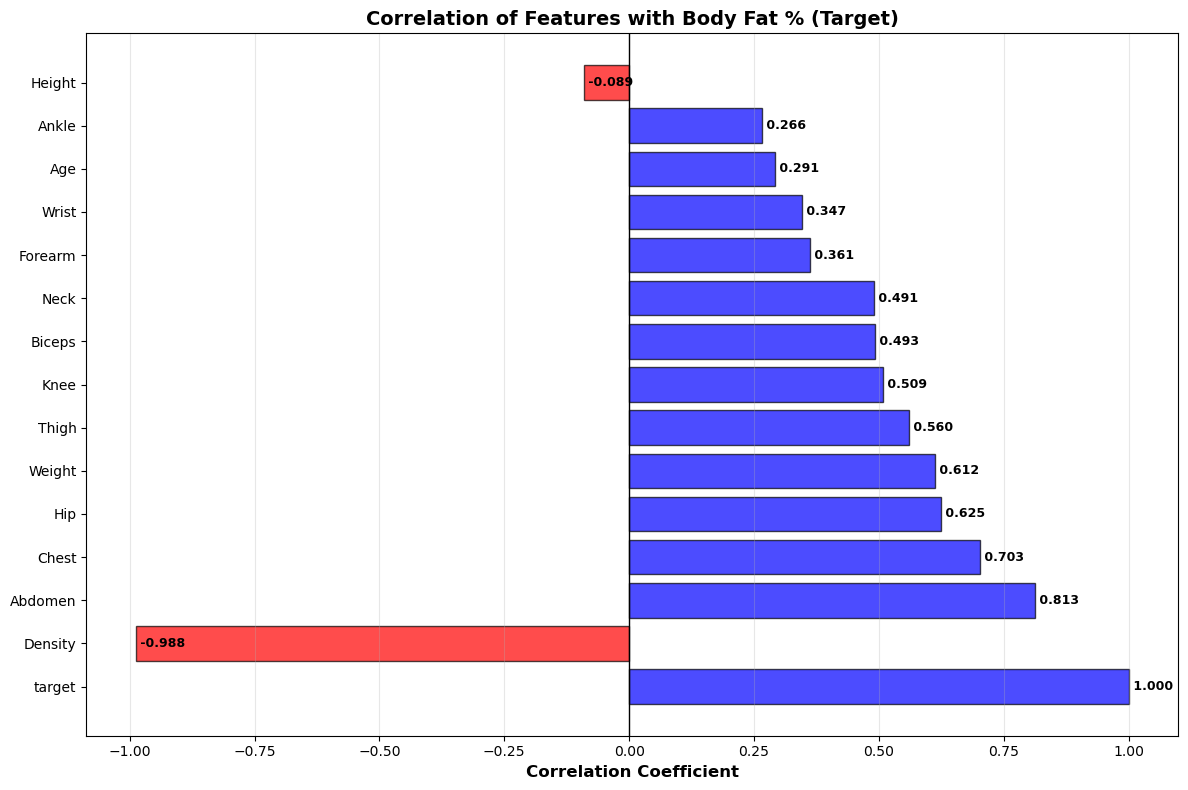

In [341]:
# ============================================================================
# 7. CORRELATION ANALYSIS
# ============================================================================
# Purpose: Calculate and visualize correlations between all features and the 
#          target variable to identify the most predictive features
# Uses: numeric_cols from Section 2
# Calculates: correlations_with_target
# ============================================================================
print("\n" + "=" * 80)
print("7. CORRELATION WITH TARGET")
print("=" * 80)

# Calculate correlations with target (first time)
correlations_with_target = df[numeric_cols].corrwith(df['target']).sort_values(key=abs, ascending=False)

# Create correlation table using correlations calculated above
corr_table = pd.DataFrame({
    'Feature': correlations_with_target.index,
    'Correlation': correlations_with_target.values,
    '|Correlation|': correlations_with_target.abs().values,
    'R²': correlations_with_target.values ** 2,
    'Strength': ['Very Strong' if abs(x) > 0.8 else 'Strong' if abs(x) > 0.6 else 'Moderate' if abs(x) > 0.4 else 'Weak' for x in correlations_with_target.values],
    'Direction': ['Positive' if x > 0 else 'Negative' for x in correlations_with_target.values]
})

# Display with enhanced styling
display(corr_table.style.format({
    'Correlation': '{:.6f}',
    '|Correlation|': '{:.6f}',
    'R²': '{:.6f}'
}).background_gradient(subset=['Correlation'], cmap='RdYlGn_r', vmin=-1, vmax=1)
  .background_gradient(subset=['|Correlation|'], cmap='YlOrRd', vmin=0, vmax=1)
  .set_caption('Correlation with Target (Sorted by Absolute Value)')
  .set_table_styles([
      {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), 
                                        ('text-align', 'center'), ('padding', '10px')]},
      {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), 
                                  ('font-weight', 'bold'), ('text-align', 'center')]},
      {'selector': 'td', 'props': [('text-align', 'center')]}
  ]))

# Visualize correlations with target
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['red' if x < 0 else 'blue' for x in correlations_with_target.values]
bars = ax.barh(range(len(correlations_with_target)), correlations_with_target.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(correlations_with_target)))
ax.set_yticklabels(correlations_with_target.index, fontsize=10)
ax.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Correlation of Features with Body Fat % (Target)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (idx, val) in enumerate(correlations_with_target.items()):
    ax.text(val, i, f' {val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**7. Correlation with Target**
This section evaluates the linear associations between each input feature and the target variable (body fat percentage) using Pearson correlation coefficients. Features are ranked based on the absolute magnitude of their correlations to identify the most informative predictors. A horizontal bar chart visualizes these relationships, with positively correlated variables (those that increase with body fat) displayed in blue and negatively correlated variables shown in red.

The analysis highlights that measurements such as abdomen and chest circumference exhibit strong positive correlations with body fat percentage, whereas density shows a strong negative correlation—consistent with the well-established inverse relationship between body density and fat mass. This ranked correlation structure provides a foundation for feature selection, helping prioritize variables that are likely to contribute most effectively to predictive modeling efforts.


In [342]:
# ============================================================================
# 8. PAIRWISE CORRELATION HEATMAP (for feature relationships)
# ============================================================================
# Purpose: Analyze pairwise correlations among all numeric features to identify 
#          multicollinearity patterns
# Uses: numeric_cols from Section 2
# Calculates: correlation_matrix, plot_correlation_matrix() function
# ============================================================================
print("\n" + "=" * 80)
print("8. FEATURE-FEATURE CORRELATION MATRIX")
print("=" * 80)

# Calculate correlation matrix (first time)
correlation_matrix = df[numeric_cols].corr()


8. FEATURE-FEATURE CORRELATION MATRIX


In [343]:
# ============================================================================
# Define reusable function for correlation matrix plot 
# ============================================================================
def plot_correlation_matrix(ax=None, figsize=(14, 12), title_suffix=""):
    """
    Plot feature-feature correlation matrix heatmap.
    
    This function creates a heatmap visualization of the correlation matrix
    showing pairwise correlations among all numeric features. The heatmap:
    - Uses a coolwarm colormap (red=positive, blue=negative)
    - Displays correlation values as text annotations
    - Helps identify multicollinearity patterns
    - Includes a colorbar for reference
    
    The visualization is essential for understanding feature relationships
    and identifying redundant features that might cause multicollinearity
    issues in regression models.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes, optional
        Axis to plot on. If None, creates a new figure (standalone mode).
        If provided, plots on the given axis (grid mode).
    figsize : tuple, default (14, 12)
        Figure size for standalone plots. Ignored if ax is provided.
    title_suffix : str, default ""
        Additional text to append to the title (e.g., "\n(Multicollinearity Patterns)").
    
    Returns:
    --------
    matplotlib.axes.Axes
        The axes object with the plot.
    
    Uses:
    -----
    - correlation_matrix : Calculated in Section 8 before function definition
    - numeric_cols : Created in Section 2
    
    Notes:
    ------
    - Correlation values are displayed as text annotations on each cell
    - Values range from -1 (perfect negative) to +1 (perfect positive)
    - Strong correlations (|r| > 0.7) are particularly noteworthy
    - The function is defined in Section 8 and reused in "3 interesting charts"
    
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    im = ax.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    
    ax.set_xticks(range(len(correlation_matrix.columns)))
    ax.set_yticks(range(len(correlation_matrix.columns)))
    ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(correlation_matrix.columns, fontsize=9)
    ax.set_title(f'Correlation Matrix - All Features{title_suffix}', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Add correlation values
    for i in range(len(correlation_matrix.columns)):
        for j in range(len(correlation_matrix.columns)):
            text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=7)
    
    plt.colorbar(im, ax=ax, label='Correlation Coefficient')
    
    if ax is None:
        plt.tight_layout()
        plt.show()
    return ax

<Axes: title={'center': 'Correlation Matrix - All Features'}>

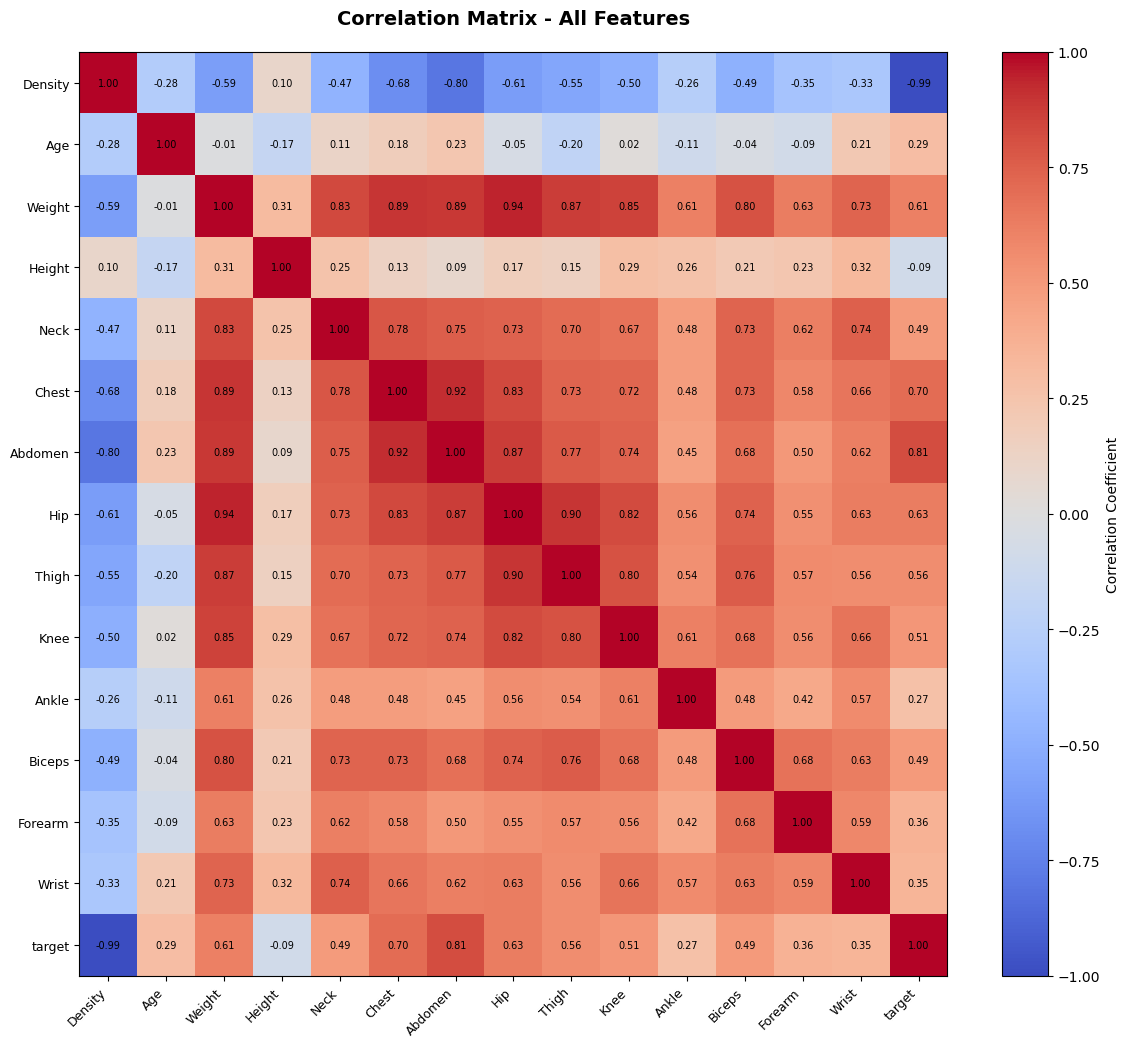

In [344]:
plot_correlation_matrix(figsize=(14, 12))

**8. Feature–Feature Correlation Matrix**
This section analyzes the pairwise correlations among all numeric features using a correlation heatmap. The visualization helps identify multicollinearity, where two or more input variables are highly correlated, potentially indicating redundancy in the feature set. For example, several body circumference measurements show strong positive correlations, suggesting they capture similar information. Recognizing these relationships is important for model interpretability and can help anticipate multicollinearity issues in regression models. The heatmap employs a color gradient to convey the strength and direction of correlations: strong positive correlations appear in red, strong negative correlations in blue, and weak or negligible correlations in lighter shades. This provides a comprehensive overview of how the features relate to each other within the dataset.



9. TARGET DISTRIBUTION ANALYSIS

TARGET QUARTILE RANGES


,Quartile,Min Body Fat %,Max Body Fat %,Count
0,Q1 (Low),0.00,12.40,63
1,Q2,12.50,19.20,64
2,Q3,19.30,25.30,64
3,Q4 (High),25.40,47.50,61



MEAN VALUES OF KEY FEATURES BY TARGET QUARTILE


,Quartile,Age,Weight,Abdomen,Chest,Hip
0,Q1 (Low),40.16,158.55,82.48,94.13,94.87
1,Q2,44.38,170.54,88.83,98.59,97.91
2,Q3,43.42,185.58,94.96,102.03,101.62
3,Q4 (High),51.84,201.77,104.35,108.82,105.39



--------------------------------------------------------------------------------
VISUALIZATION: Mean Values by Target Quartile
--------------------------------------------------------------------------------


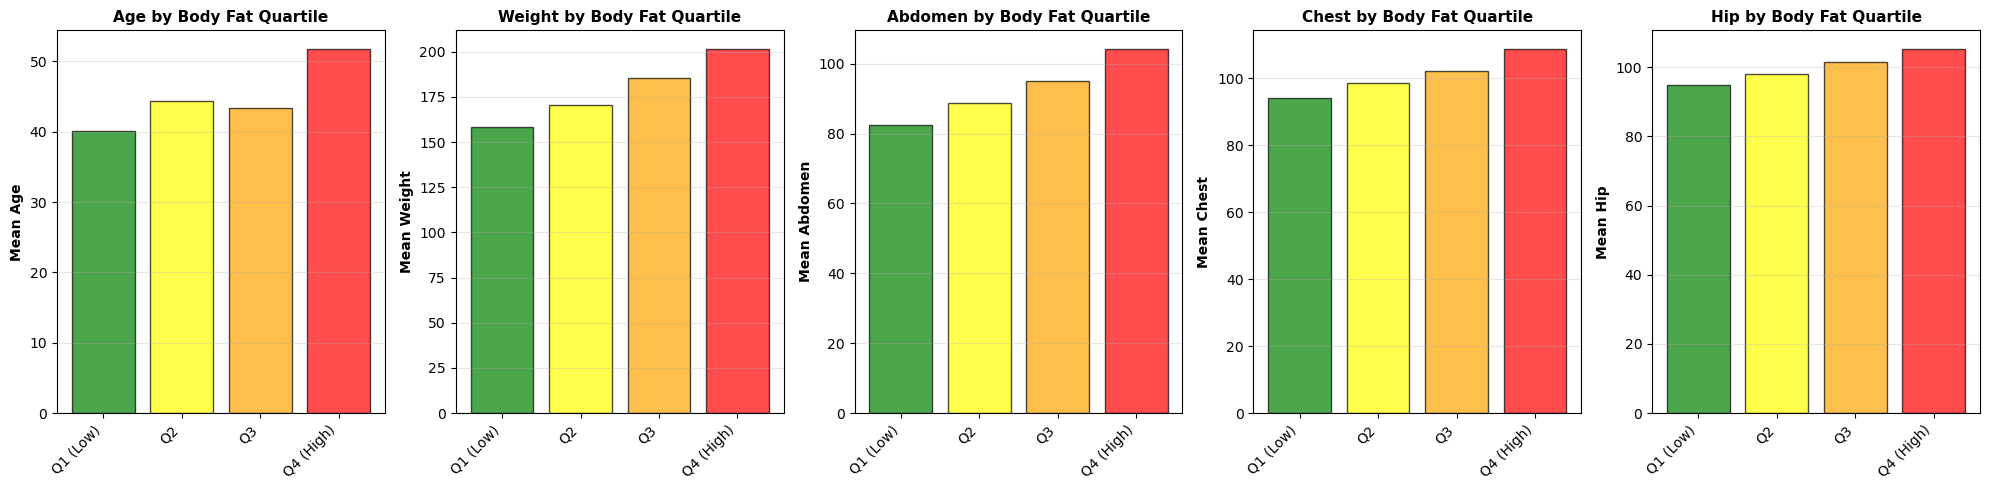

In [345]:
# ============================================================================
# 9. SUMMARY STATISTICS BY TARGET QUARTILES
# ============================================================================
# Purpose: Segment target variable into quartiles and examine how key features 
#          vary across different body fat levels
# Uses: target_quartile from Section 6a
# Calculates: target_quartile_stats, quartile_ranges, quartile_summary
# ============================================================================
print("\n" + "=" * 80)
print("9. TARGET DISTRIBUTION ANALYSIS")
print("=" * 80)

# Use target_quartile created in Section 6a
key_features_analysis = ['Age', 'Weight', 'Abdomen', 'Chest', 'Hip']

# Calculate statistics by target quartiles (first time)
target_quartile_stats = {}
for feat in key_features_analysis:
    target_quartile_stats[feat] = df.groupby('target_quartile', observed=True)[feat].mean()

# ============================================================================
# Table 1: Target Quartile Ranges (using target_quartile from Section 6a)
# ============================================================================
print("\n" + "=" * 80)
print("TARGET QUARTILE RANGES")
print("=" * 80)

quartile_ranges = df.groupby('target_quartile', observed=True)['target'].agg(['min', 'max', 'count']).reset_index()
quartile_ranges.columns = ['Quartile', 'Min Body Fat %', 'Max Body Fat %', 'Count']

# Display quartile ranges table with styling
display(quartile_ranges.style.format({
    'Min Body Fat %': '{:.2f}',
    'Max Body Fat %': '{:.2f}',
    'Count': '{:.0f}'
}).background_gradient(subset=['Min Body Fat %', 'Max Body Fat %'], cmap='YlOrRd')
  .set_caption('Target Quartile Ranges')
  .set_table_styles([
      {'selector': 'caption', 
       'props': [('font-size', '14px'), ('font-weight', 'bold'), 
                 ('text-align', 'center'), ('padding', '10px')]},
      {'selector': 'th', 
       'props': [('background-color', '#4472C4'), ('color', 'white'), 
                ('font-weight', 'bold'), ('text-align', 'center')]},
      {'selector': 'td', 
       'props': [('text-align', 'center'), ('padding', '6px')]}
  ]))

# ============================================================================
# Table 2: Mean Values by Quartile (using target_quartile_stats calculated above)
# ============================================================================
print("\n" + "=" * 80)
print("MEAN VALUES OF KEY FEATURES BY TARGET QUARTILE")
print("=" * 80)

quartile_summary = pd.DataFrame({
    'Quartile': ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
})
for feat in key_features_analysis:
    quartile_summary[feat] = [target_quartile_stats[feat][q] for q in ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']]

# Display quartile summary table with styling
display(quartile_summary.style.format({
    'Age': '{:.2f}',
    'Weight': '{:.2f}',
    'Abdomen': '{:.2f}',
    'Chest': '{:.2f}',
    'Hip': '{:.2f}'
}).background_gradient(subset=key_features_analysis, cmap='YlOrRd', axis=0)
  .set_caption('Mean Values of Key Features by Target Quartile')
  .set_table_styles([
      {'selector': 'caption', 
       'props': [('font-size', '14px'), ('font-weight', 'bold'), 
                 ('text-align', 'center'), ('padding', '10px')]},
      {'selector': 'th', 
       'props': [('background-color', '#4472C4'), ('color', 'white'), 
                ('font-weight', 'bold'), ('text-align', 'center')]},
      {'selector': 'td', 
       'props': [('text-align', 'center'), ('padding', '6px')]}
  ]))

# ============================================================================
# Visualization: Bar charts showing mean values by quartile for each feature
# ============================================================================
print("\n" + "-" * 80)
print("VISUALIZATION: Mean Values by Target Quartile")
print("-" * 80)

fig, axes = plt.subplots(1, len(key_features_analysis), figsize=(20, 5))
for i, feat in enumerate(key_features_analysis):
    quartile_means = target_quartile_stats[feat]  # Use stats calculated above
    axes[i].bar(range(len(quartile_means)), quartile_means.values, 
                color=['green', 'yellow', 'orange', 'red'], alpha=0.7, edgecolor='black')
    axes[i].set_xticks(range(len(quartile_means)))
    axes[i].set_xticklabels(quartile_means.index, rotation=45, ha='right')
    axes[i].set_ylabel(f'Mean {feat}', fontsize=10, fontweight='bold')
    axes[i].set_title(f'{feat} by Body Fat Quartile', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**9. Summary Statistics by Target Quartiles**
This section segments the target variable (body fat percentage) into quartiles to examine how key features vary across different levels of body fat. By dividing the dataset into four groups—Q1 (lowest body fat), Q2, Q3, and Q4 (highest body fat)—the analysis uncovers systematic differences in body measurements and demographic characteristics between individuals with low and high body fat percentages.

Two summary tables present the quartile boundaries and the mean values of key features (Age, Weight, Abdomen, Chest, Hip) for each quartile group. Complementary bar charts visualize these trends, revealing clear monotonic increases in measurements such as abdomen and chest circumference as body fat quartiles rise. This stratified approach provides a deeper understanding of how feature-target relationships vary across the distribution of body fat, highlighting patterns that may be obscured when analyzing the dataset in aggregate.


In [346]:
# ============================================================================
# 10. AGE ANALYSIS
# ============================================================================
# Purpose: Analyze the relationship between age and body fat percentage using 
#          scatter plots and age group comparisons
# Uses: regression_coeffs['Age'] from Section 6a
# Calculates: age_group, age_group_stats, plot_age_vs_bodyfat() function
# ============================================================================
print("\n" + "=" * 80)
print("10. AGE VS BODY FAT ANALYSIS")
print("=" * 80)

# Create age groups 
df['age_group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100], 
                         labels=['<30', '30-40', '40-50', '50-60', '60+'])

# Calculate age group statistics 
age_group_stats = df.groupby('age_group', observed=True)['target'].agg(['mean', 'std', 'count'])

# Use regression coefficients for Age from Section 6a 
age_coeffs = regression_coeffs['Age']


10. AGE VS BODY FAT ANALYSIS


In [347]:
# ============================================================================
# function for Age vs Body Fat plot 
# ============================================================================
def plot_age_vs_bodyfat(ax_scatter=None, ax_bar=None, figsize=(16, 6), title_suffix=""):
    """
    Plot Age vs Body Fat analysis (scatter plot + bar chart).
    
    This function creates a two-panel visualization analyzing the relationship
    between age and body fat percentage:
    - Left panel: Scatter plot with color coding by age and regression line
    - Right panel: Bar chart showing mean body fat by age groups
    
    The visualization helps understand how age relates to body fat and whether
    there are distinct patterns across different age groups.
    
    Parameters:
    -----------
    ax_scatter : matplotlib.axes.Axes, optional
        Axis for the scatter plot. If None, creates a new figure with two subplots.
    ax_bar : matplotlib.axes.Axes, optional
        Axis for the bar chart. If None, creates a new figure with two subplots.
        Both ax_scatter and ax_bar must be provided together, or both None.
    figsize : tuple, default (16, 6)
        Figure size for standalone plots. Ignored if axes are provided.
    title_suffix : str, default ""
        Additional text to append to titles (e.g., "\n(Age-Related Patterns)").
    
    Returns:
    --------
    tuple of matplotlib.axes.Axes
        (ax_scatter, ax_bar) - The axes objects with the plots.
    
    Uses:
    -----
    - regression_coeffs['Age'] : Calculated in Section 6a
    - age_group : Created in Section 10 before function definition
    - age_group_stats : Calculated in Section 10 before function definition
    
    Notes:
    ------
    - The scatter plot uses a viridis colormap to show age progression
    - Age groups: <30, 30-40, 40-50, 50-60, 60+
    - Bar chart includes error bars showing standard deviation
    - The function is defined in Section 10 and reused in "3 interesting charts"
    
    """
    if ax_scatter is None or ax_bar is None:
        fig, (ax_scatter, ax_bar) = plt.subplots(1, 2, figsize=figsize)
    
    age_coeffs = regression_coeffs['Age']
    age_group_means = age_group_stats['mean']
    age_group_stds = age_group_stats['std']
    
    # Scatter plot
    scatter = ax_scatter.scatter(df['Age'], df['target'], 
                                 c=df['Age'], cmap='viridis',
                                 alpha=0.8, s=100, edgecolors='white', linewidth=1.5,
                                 vmin=df['Age'].min(), vmax=df['Age'].max())
    
    ax_scatter.plot(df['Age'], age_coeffs['poly_func'](df['Age']), 
                    "red", linestyle='--', linewidth=3, alpha=0.9, 
                    label=f'Linear Fit (r={age_coeffs["correlation"]:.3f})', zorder=1)
    
    ax_scatter.set_xlabel('Age (years)', fontsize=12, fontweight='bold')
    ax_scatter.set_ylabel('Body Fat %', fontsize=12, fontweight='bold')
    ax_scatter.set_title(f'Age vs Body Fat % (Color by Age){title_suffix}', 
                         fontsize=13, fontweight='bold')
    ax_scatter.grid(True, alpha=0.3, linestyle='--', zorder=0)
    
    corr_age = df['Age'].corr(df['target'])
    ax_scatter.text(0.05, 0.95, f'Correlation: {corr_age:.3f}', transform=ax_scatter.transAxes,
                    fontsize=11, verticalalignment='top', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, 
                             edgecolor='black', linewidth=1.5))
    ax_scatter.legend(loc='lower right', fontsize=9, framealpha=0.95, fancybox=True, shadow=True)
    
    cbar = plt.colorbar(scatter, ax=ax_scatter, shrink=0.8, pad=0.02)
    cbar.set_label('Age (years)', fontsize=10, fontweight='bold', rotation=270, labelpad=15)
    cbar.ax.tick_params(labelsize=9)
    
    # Bar chart
    bar_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
    bars = ax_bar.bar(range(len(age_group_means)), age_group_means.values,
               color=bar_colors, alpha=0.9, edgecolor='white', linewidth=2)
    
    for i, (bar, value) in enumerate(zip(bars, age_group_means.values)):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{value:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold',
                    color='black')
    
    ax_bar.set_xticks(range(len(age_group_means)))
    ax_bar.set_xticklabels(age_group_means.index, fontsize=11, fontweight='bold')
    ax_bar.set_ylabel('Mean Body Fat %', fontsize=12, fontweight='bold')
    ax_bar.set_xlabel('Age Group', fontsize=12, fontweight='bold')
    ax_bar.set_title(f'Mean Body Fat % by Age Group (Color Coded){title_suffix}', 
                     fontsize=13, fontweight='bold')
    ax_bar.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    from matplotlib.patches import Rectangle
    legend_elements = [Rectangle((0,0),1,1, facecolor=bar_colors[i], 
                                 alpha=0.9, edgecolor='white', linewidth=2, 
                                 label=group) for i, group in enumerate(age_group_means.index)]
    ax_bar.legend(handles=legend_elements, loc='upper left', fontsize=9, 
                  framealpha=0.95, fancybox=True, shadow=True, title='Age Groups',
                  title_fontsize=10)
    
    if ax_scatter is None:
        plt.tight_layout()
        plt.show()
    return ax_scatter, ax_bar




Mean body fat by age group:


,mean,std,count
age_group,,,
<30,14.368421,7.414489,38
30-40,17.244444,7.500658,54
40-50,20.767857,8.224342,84
50-60,18.373171,9.049835,41
60+,24.314285,6.485556,35


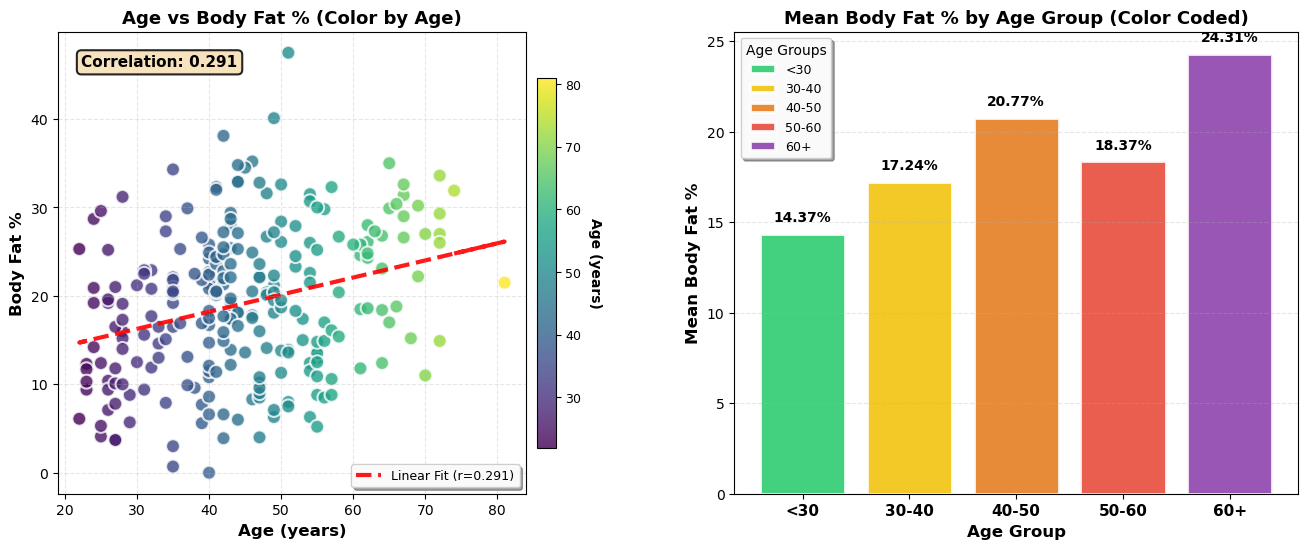

In [348]:
# Now use the function to plot
plot_age_vs_bodyfat(figsize=(16, 6))

# Display statistics table
print("\nMean body fat by age group:")
display(age_group_stats.style.format({
    'mean': '{:.6f}',
    'std': '{:.6f}',
    'count': '{:.0f}'
}).background_gradient(subset=['mean'], cmap='YlOrRd')
  .set_caption('Mean Body Fat by Age Group')
  .set_table_styles([
      {'selector': 'caption', 
       'props': [('font-size', '14px'), ('font-weight', 'bold'), 
                 ('text-align', 'center'), ('padding', '10px')]},
      {'selector': 'th', 
       'props': [('background-color', '#4472C4'), ('color', 'white'), 
                ('font-weight', 'bold'), ('text-align', 'center')]},
      {'selector': 'td', 
       'props': [('text-align', 'center'), ('padding', '6px')]}
  ]))

**10. Age vs Body Fat Analysis**
This section investigates the relationship between age and body fat percentage to assess whether age serves as a meaningful predictor of body fat levels. The analysis incorporates a scatter plot—color-coded by age—with a fitted regression line to illustrate the overall linear trend, alongside a bar chart summarizing the mean body fat percentage within predefined age categories (<30, 30–40, 40–50, 50–60, 60+). Together, these visualizations highlight potential age-related patterns, such as gradual increases in body fat that may align with metabolic and physiological changes over time. The correlation coefficient provides a quantitative measure of the strength and direction of this association, while the age-group comparison offers a more detailed understanding of how body fat distribution shifts across different stages of adulthood.



11. BODY MEASUREMENTS SUMMARY


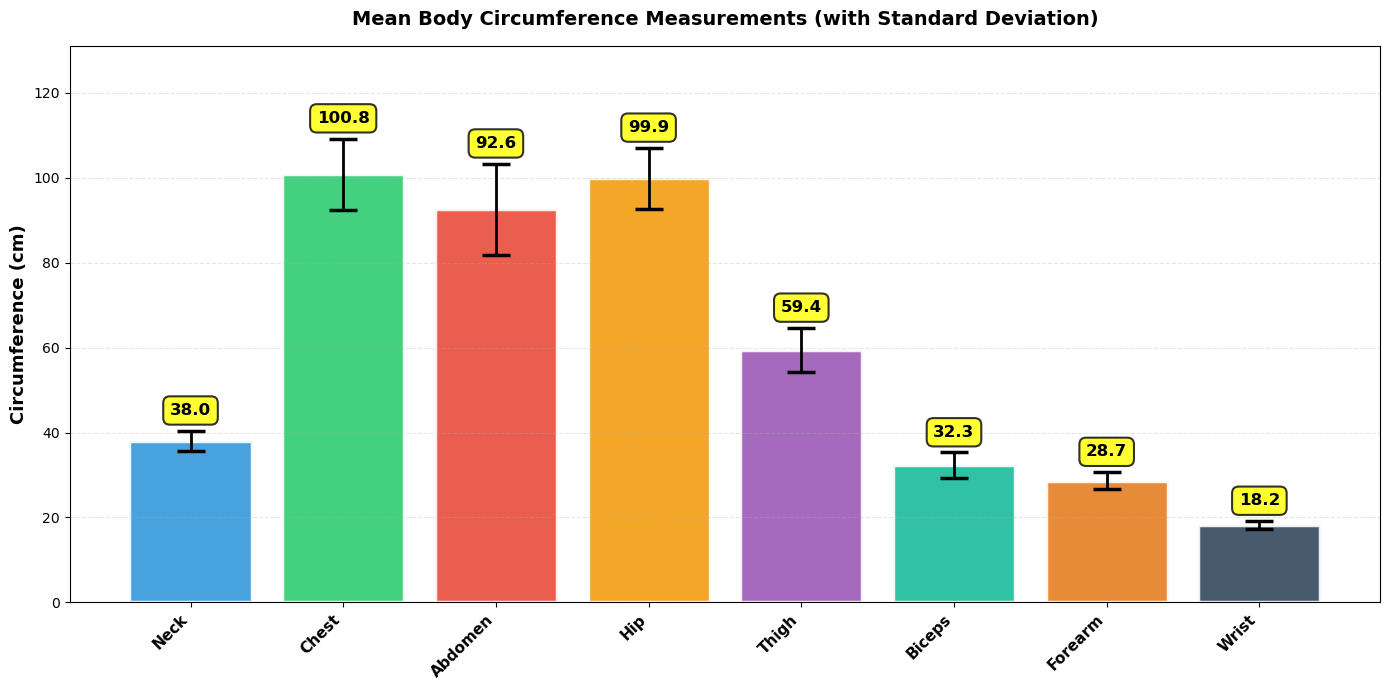

In [349]:
# ============================================================================
# 11. BODY MEASUREMENTS SUMMARY
# ============================================================================
# Purpose: Compare and visualize body measurements (circumferences) to identify 
#          patterns and relationships
# Uses: basic_stats from Section 2
# Calculates: body_measurements (if any new calculations)
# ============================================================================
print("\n" + "=" * 80)
print("11. BODY MEASUREMENTS SUMMARY")
print("=" * 80)

# Calculate circumference statistics (first time)
circumference_features = ['Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Biceps', 'Forearm', 'Wrist']
circ_mean = df[circumference_features].mean()
circ_std = df[circumference_features].std()

# Create visualization using circ_mean and circ_std calculated above
fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(len(circumference_features))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

bars = ax.bar(x_pos, circ_mean.values, yerr=circ_std.values, 
              alpha=0.9, color=colors, edgecolor='white', linewidth=2.5, 
              capsize=10, error_kw={'elinewidth': 2, 'ecolor': 'black', 'capthick': 2.5})

# Add mean value labels on top of bars
for i, (bar, mean_val, std_val) in enumerate(zip(bars, circ_mean.values, circ_std.values)):
    # Position label above error bar
    label_y = bar.get_height() + std_val + 3
    
    ax.text(bar.get_x() + bar.get_width()/2, label_y,
            f'{mean_val:.1f}', 
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8, 
                     edgecolor='black', linewidth=1.5))

ax.set_xticks(x_pos)
ax.set_xticklabels(circumference_features, rotation=45, ha='right', fontsize=11, fontweight='bold')
ax.set_ylabel('Circumference (cm)', fontsize=13, fontweight='bold')
ax.set_title('Mean Body Circumference Measurements (with Standard Deviation)', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Set y-axis limit to accommodate labels
ax.set_ylim(bottom=0, top=max(circ_mean.values + circ_std.values) * 1.2)

plt.tight_layout()
plt.show()

**11. Body Measurements Comparison**
This section presents a comparative summary of all body circumference measurements—Neck, Chest, Abdomen, Hip, Thigh, Biceps, Forearm, and Wrist—within a single visualization. A bar chart displays the mean value for each measurement, complemented by error bars representing the standard deviation to illustrate the variability across individuals. This comparison highlights which body measurements tend to have larger average values (such as Chest and Abdomen) and which are relatively smaller (such as Wrist and Neck). Observing the relative scales and dispersion of these features provides useful context for subsequent modeling decisions, particularly when considering normalization or feature scaling. The inclusion of value labels on each bar further supports precise comparison of mean circumferences across all measurements.


## Three Most Interesting Charts


After completing the comprehensive exploratory analysis, I identified three charts that I found particularly insightful:
1. Abdomen vs Body Fat % Scatter Plot - Demonstrates the strongest positive correlation
2. Feature-Feature Correlation Matrix Heatmap - Reveals multicollinearity patterns
3. Age vs Body Fat % Analysis - Shows interesting age-related patterns

CHART 1: ABDOMEN VS BODY FAT %


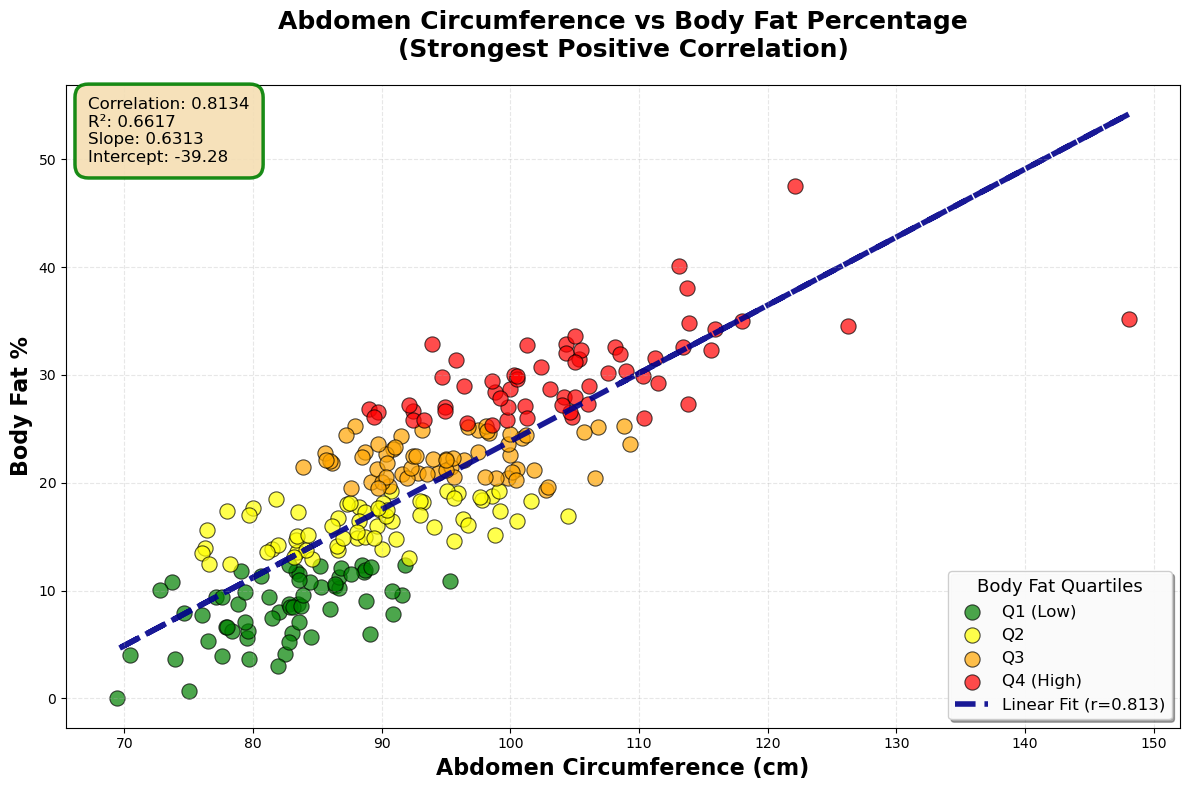


CHART 2: FEATURE-FEATURE CORRELATION MATRIX

CHART 3: AGE VS BODY FAT % ANALYSIS


(<Axes: title={'center': 'Age vs Body Fat % (Color by Age)'}, xlabel='Age (years)', ylabel='Body Fat %'>,
 <Axes: title={'center': 'Mean Body Fat % by Age Group (Color Coded)'}, xlabel='Age Group', ylabel='Mean Body Fat %'>)

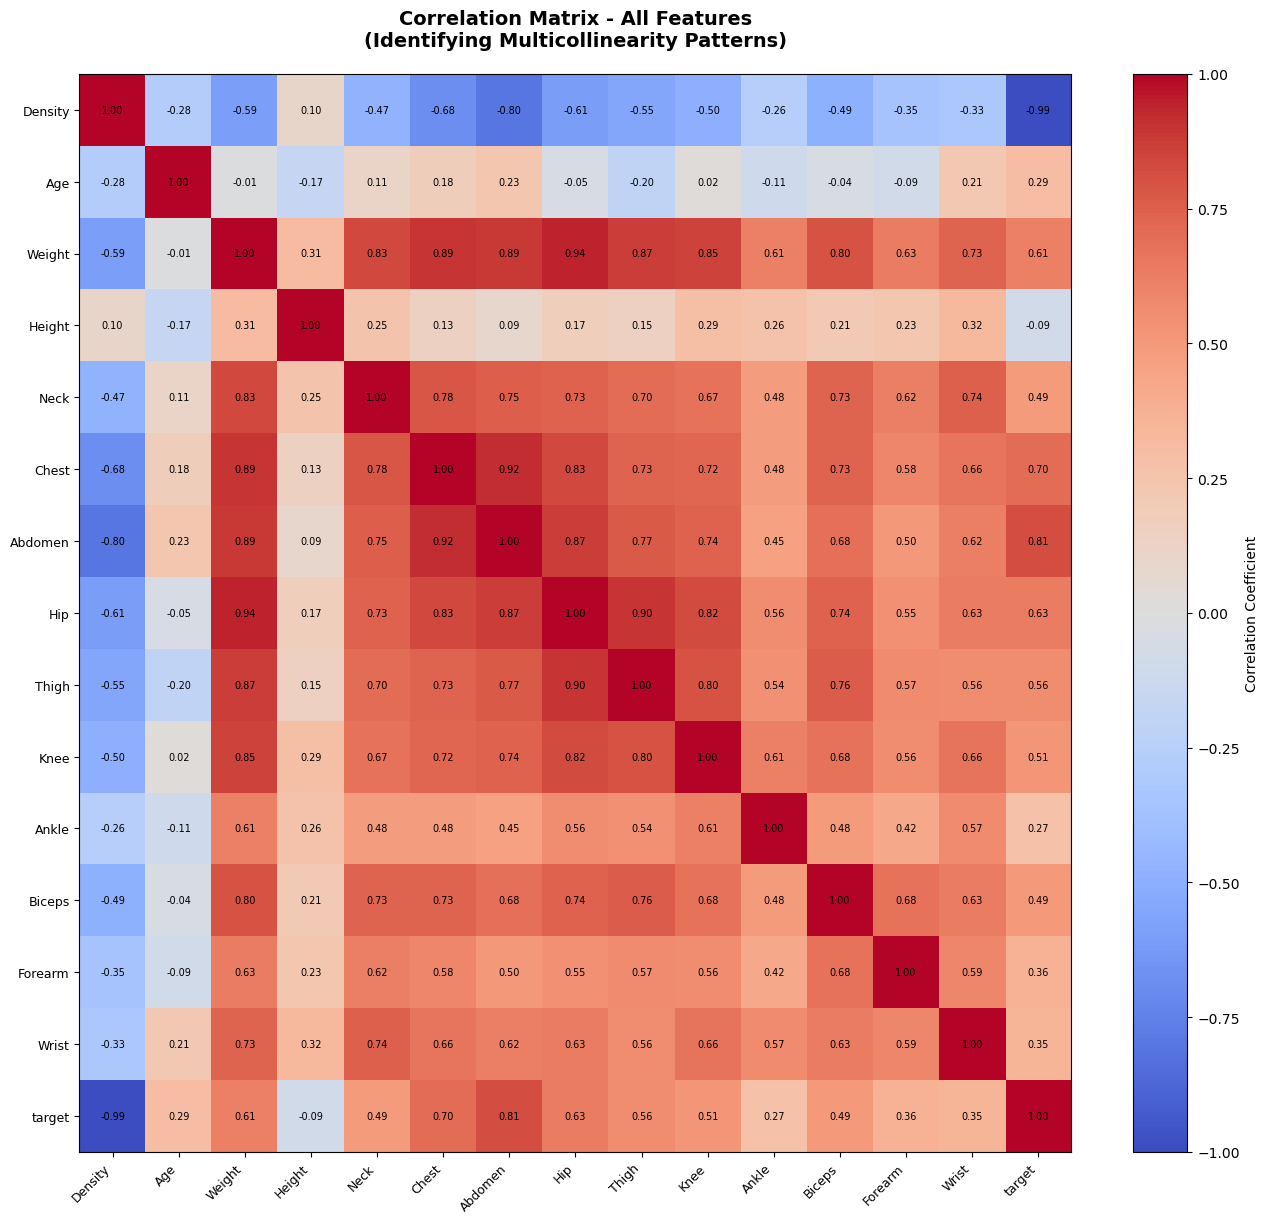

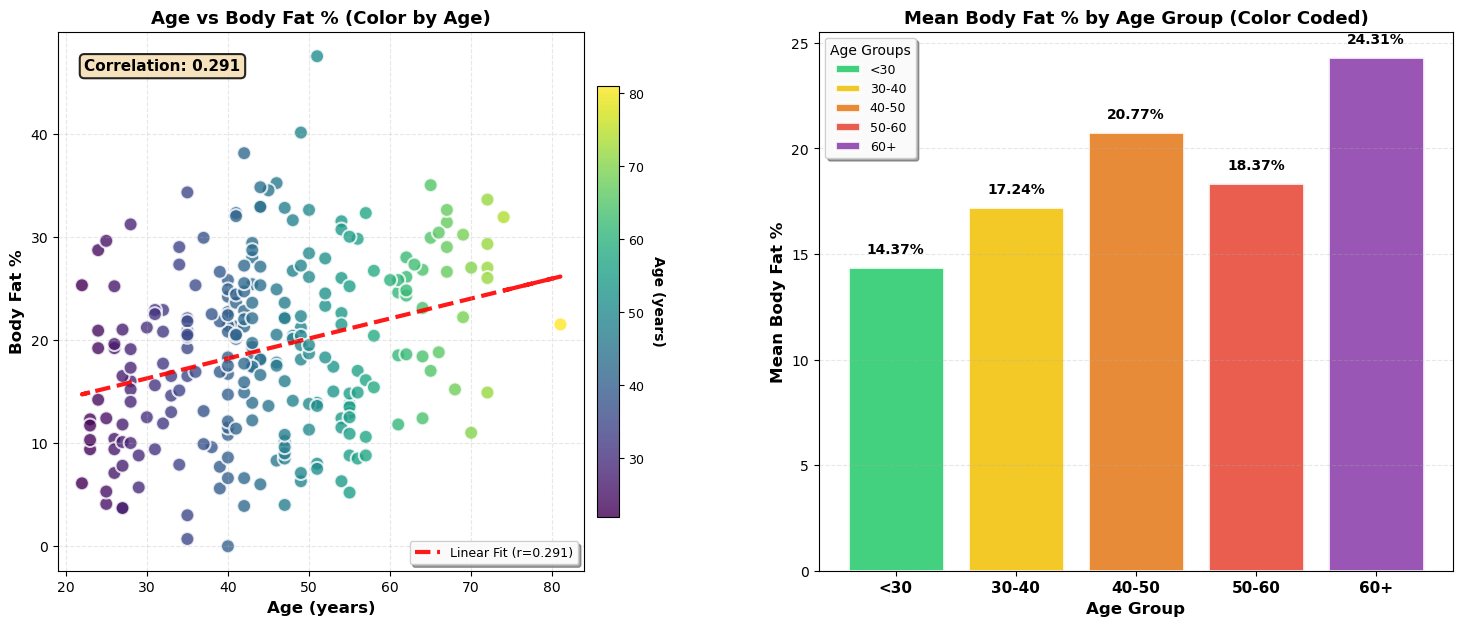

In [350]:

print("\nAfter completing the comprehensive exploratory analysis, I identified three charts that I found particularly insightful:")
print("1. Abdomen vs Body Fat % Scatter Plot - Demonstrates the strongest positive correlation")
print("2. Feature-Feature Correlation Matrix Heatmap - Reveals multicollinearity patterns")
print("3. Age vs Body Fat % Analysis - Shows interesting age-related patterns\n")

# Chart 1: Abdomen vs Body Fat (function already defined in Section 6a)
print("=" * 80)
print("CHART 1: ABDOMEN VS BODY FAT %")
print("=" * 80)
plot_abdomen_vs_bodyfat(figsize=(12, 8), title_suffix="\n(Strongest Positive Correlation)")

# Chart 2: Correlation Matrix (function already defined in Section 8)
print("\n" + "=" * 80)
print("CHART 2: FEATURE-FEATURE CORRELATION MATRIX")
print("=" * 80)
plot_correlation_matrix(figsize=(16, 14), title_suffix="\n(Identifying Multicollinearity Patterns)")

# Chart 3: Age vs Body Fat (function already defined in Section 10)
print("\n" + "=" * 80)
print("CHART 3: AGE VS BODY FAT % ANALYSIS")
print("=" * 80)
plot_age_vs_bodyfat(figsize=(18, 7))



**Chart 1: Abdomen vs Body Fat %**

The Abdomen scatter plot reveals the strongest positive correlation (r ≈ 0.81) with body fat percentage among all features in the dataset. This relationship is nearly linear, with a clear upward trend indicating that as abdominal circumference increases, body fat percentage increases proportionally. 

The color coding by target quartiles shows a clear separation: individuals in the green quartile (low body fat, Q1) cluster in the lower-left region of the plot, while those in the red quartile (high body fat, Q4) cluster in the upper-right region. This visual separation demonstrates that abdominal circumference alone could be a powerful predictor of body fat percentage.

The R² value of approximately 0.66 indicates that abdominal measurements explain about two-thirds of the variance in body fat percentage, making it the most informative single feature for prediction. This strong relationship makes biological sense, as abdominal fat is a key component of total body fat, and abdominal circumference measurements are commonly used in clinical settings to estimate body composition.

The regression line (blue dashed) fits the data well, with minimal scatter around it, suggesting a reliable linear relationship. This finding is particularly valuable for model building, as it suggests that a simple linear model using only abdominal circumference could provide reasonably accurate predictions.

**Chart 2: Feature-Feature Correlation Matrix**


The correlation heatmap reveals significant multicollinearity among body measurements, which is a critical finding for model building. Notably, measurements like Chest, Abdomen, Hip, and Weight show strong positive correlations (r > 0.8) with each other, indicating that these features capture similar information about body size and composition.

This multicollinearity is expected from a biological perspective, as larger individuals tend to have larger measurements across all body parts. However, this redundancy could pose challenges for regression models, as highly correlated features can lead to unstable coefficient estimates, inflated standard errors, and difficulties in interpreting which features are truly driving the relationship with body fat.

The heatmap also reveals that Density has a very strong negative correlation (r ≈ -0.99) with body fat percentage, which makes perfect physical sense: higher body density corresponds to lower body fat (more muscle/bone mass relative to fat). This near-perfect negative correlation suggests that Density and body fat percentage are essentially measuring opposite aspects of the same underlying construct.

Additionally, the visualization helps identify feature pairs that might be redundant. The most highly correlated pair is Weight and Hip (r ≈ 0.94), which suggests these features capture very similar information about body size. Other strongly correlated pairs include Chest and Abdomen, as well as Weight with other body measurements. When building regression models, we might consider using only one feature from such highly correlated pairs to reduce dimensionality and improve model stability. This insight is valuable for feature selection and dimensionality reduction techniques like PCA.

**Chart 3: Age vs Body Fat % Analysis**


The age analysis reveals interesting patterns that are less straightforward than the body measurement relationships. While there is a positive correlation (r ≈ 0.29) between age and body fat percentage, the relationship is relatively weak compared to body measurements like Abdomen (r ≈ 0.81).

The scatter plot shows considerable variability, with individuals of the same age having widely different body fat percentages. This high variability suggests that age alone is not a strong predictor of body fat, and other factors (genetics, lifestyle, diet, exercise) play more significant roles.

The bar chart by age groups reveals a gradual increase in mean body fat percentage with age, but the standard deviations are substantial within each age group, indicating high variability. This pattern suggests that while age-related factors (metabolism changes, lifestyle changes, hormonal changes) may contribute to body fat accumulation over time, the effect is modest and highly variable across individuals.

The moderate correlation suggests that age-related factors play a role but are secondary to physical body measurements in determining body fat percentage. This finding is important for model building: while age should be included as a feature, it should not be expected to have the same predictive power as direct body measurements. The analysis also suggests that age might interact with other features in complex ways that simple linear relationships cannot capture.

### Problem 4 (5 points)

Plot the correlation matrix of the numeric columns in the data set.
Which pair of different columns were highlighted as the most correlated?

Most correlated pair: Weight and Hip
Correlation value: 0.940884


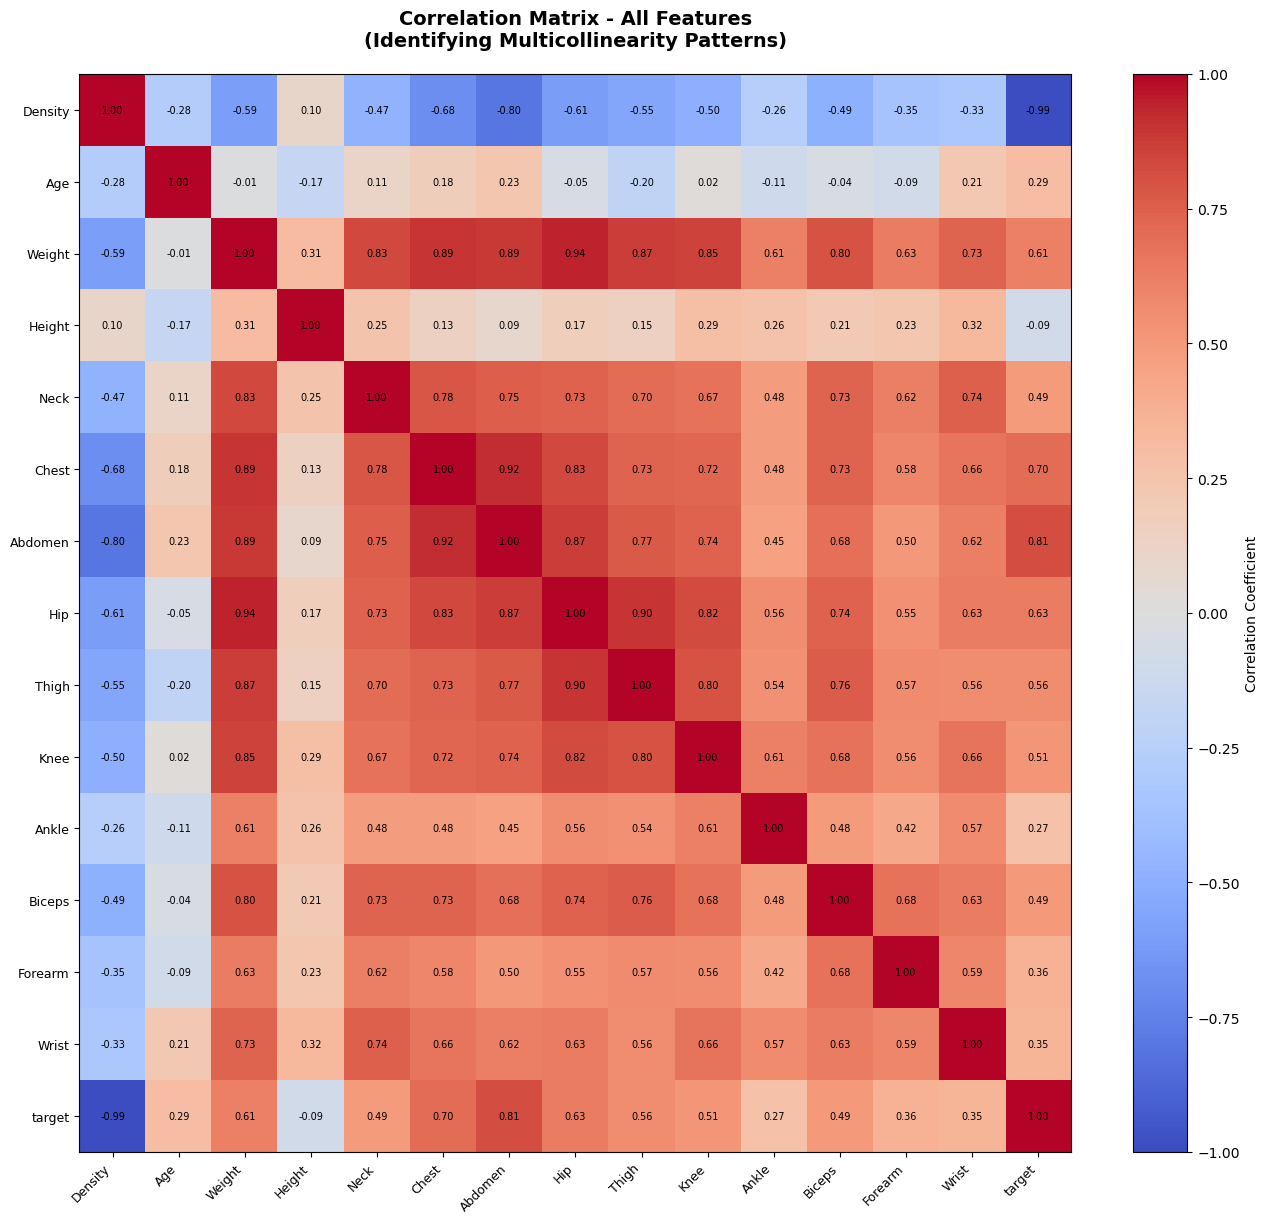

In [351]:
plot_correlation_matrix(figsize=(16, 14), title_suffix="\n(Identifying Multicollinearity Patterns)")
# Create a copy of the correlation matrix
corr_matrix = correlation_matrix.copy()

# Exclude the target column (we want feature-feature correlations only)
if 'target' in corr_matrix.columns:
    corr_matrix = corr_matrix.drop('target', axis=0).drop('target', axis=1)

# Set diagonal to NaN to exclude self-correlations
np.fill_diagonal(corr_matrix.values, np.nan)

corr_stacked = corr_matrix.stack()
max_corr_idx = corr_stacked.abs().idxmax()
max_corr_value = corr_stacked.loc[max_corr_idx]

print(f"Most correlated pair: {max_corr_idx[0]} and {max_corr_idx[1]}")
print(f"Correlation value: {max_corr_value:.6f}")


**Most correlated pair**: The most correlated pair of different columns is Weight and Hip with a correlation coefficient of 0.940884. These two measurements show a very strong positive correlation, which makes biological sense: individuals with higher body weight typically have larger hip circumference, as both measurements are indicators of overall body size and composition. This high correlation (r ≈ 0.94) suggests that these features capture similar information about body size, which could be important to consider when building regression models to avoid multicollinearity issues.

### Problem 5 (10 points)

Pick three different regression model classes to try in problem 6 from the scikit-learn documentation.
For each class, provide a link to the scikit-learn documentation, and a link to another web page describing how that kind of model works.
The second link should not be from scikit-learn, but Wikipedia is acceptable.
You do not need to understand the methods at this time, but it is good to be comfortable researching them.

In [352]:
# YOUR CODE HERE
# Import the three regression models selected for Problem 6
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

**Model 1: Linear Regression**

- **Scikit-learn Documentation**: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- **External Explanation**: https://en.wikipedia.org/wiki/Linear_regression

**Model 2: Random Forest Regressor**

- **Scikit-learn Documentation**: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
- **External Explanation**: https://en.wikipedia.org/wiki/Random_forest

**Model 3: Support Vector Regression (SVR)**

- **Scikit-learn Documentation**: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
- **External Explanation**: https://en.wikipedia.org/wiki/Support_vector_machine


### Why I selected these three models:

During my EDA, I noticed that Abdomen circumference had a very strong linear correlation with body fat (r ≈ 0.81), which made me curious: would a simple linear model be sufficient, or would non-linear methods capture additional patterns? I chose **Linear Regression** as my baseline because it directly tests whether the linear relationships I observed are sufficient for prediction. I added **Random Forest Regressor** because body composition relationships might involve feature interactions (e.g., how Age interacts with measurements) that linear models can't capture. I included **SVR** with an RBF kernel to test whether kernel-based non-linearity would improve predictions. By comparing all three, I can determine whether the strong linear correlations I found translate to good model performance, or if the relationships are more complex than they appear.

### Problem 6 (50 points)

Build three different regression models using the entire data set.
Plot the actual target vs the predicted values for each in one chart.
Compute the L2 and L1 losses for each of them.
You may use any regression class provided provided by scikit-learn, and you may reuse one class as long as you change its parameters enough to see different results.

In [353]:
# YOUR CODE HERE
# Prepare features (X) and target (y)
# Exclude 'target' column from features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != 'target']
X = df[feature_cols]
y = df['target']

# Note: For this problem, I'm using the entire dataset for training (no train/test split).
# This allows me to evaluate training performance, though it doesn't assess generalization.
# In Problem 7, I'll use cross-validation to get a better estimate of generalization performance.

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")

Features shape: (252, 14)
Target shape: (252,)

Features: ['Density', 'Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']


In [354]:
# ============================================================================
# Model 1: Linear Regression
# ============================================================================

# Using default parameters since Linear Regression has no hyperparameters
# that require tuning for this initial comparison
model_lr = LinearRegression()
model_lr.fit(X, y)
y_pred_lr = model_lr.predict(X)

# Calculate L1 and L2 losses
l1_loss_lr = np.mean(np.abs(y - y_pred_lr))
l2_loss_lr = np.mean((y - y_pred_lr) ** 2)


print(f"L1 Loss (MAE): {l1_loss_lr:.6f}")
print(f"L2 Loss (MSE): {l2_loss_lr:.6f}")



L1 Loss (MAE): 0.480196
L2 Loss (MSE): 1.527204


In [355]:
# ============================================================================
# Model 2: Random Forest Regressor
# ============================================================================

# I chose n_estimators=100 as a reasonable default that balances model complexity
# with training time. The random_state=42 ensures reproducibility of results.
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X, y)
y_pred_rf = model_rf.predict(X)

# Calculate L1 and L2 losses
l1_loss_rf = np.mean(np.abs(y - y_pred_rf))
l2_loss_rf = np.mean((y - y_pred_rf) ** 2)

print(f"L1 Loss (MAE): {l1_loss_rf:.6f}")
print(f"L2 Loss (MSE): {l2_loss_rf:.6f}")



L1 Loss (MAE): 0.139948
L2 Loss (MSE): 0.218399


In [356]:
# ============================================================================
# Model 3: Support Vector Regression (SVR)
# ============================================================================

# I used the RBF kernel with C=100 and gamma='scale'. The RBF kernel can capture
# non-linear relationships, which seemed potentially useful given the complexity of
# body composition relationships. I set C=100 as a moderate regularization value,
# and gamma='scale' automatically adjusts the kernel width based on feature variance.
model_svr = SVR(kernel='rbf', C=100, gamma='scale')
model_svr.fit(X, y)
y_pred_svr = model_svr.predict(X)

# Calculate L1 and L2 losses
l1_loss_svr = np.mean(np.abs(y - y_pred_svr))
l2_loss_svr = np.mean((y - y_pred_svr) ** 2)

print(f"L1 Loss (MAE): {l1_loss_svr:.6f}")
print(f"L2 Loss (MSE): {l2_loss_svr:.6f}")

        

L1 Loss (MAE): 3.375098
L2 Loss (MSE): 18.147752


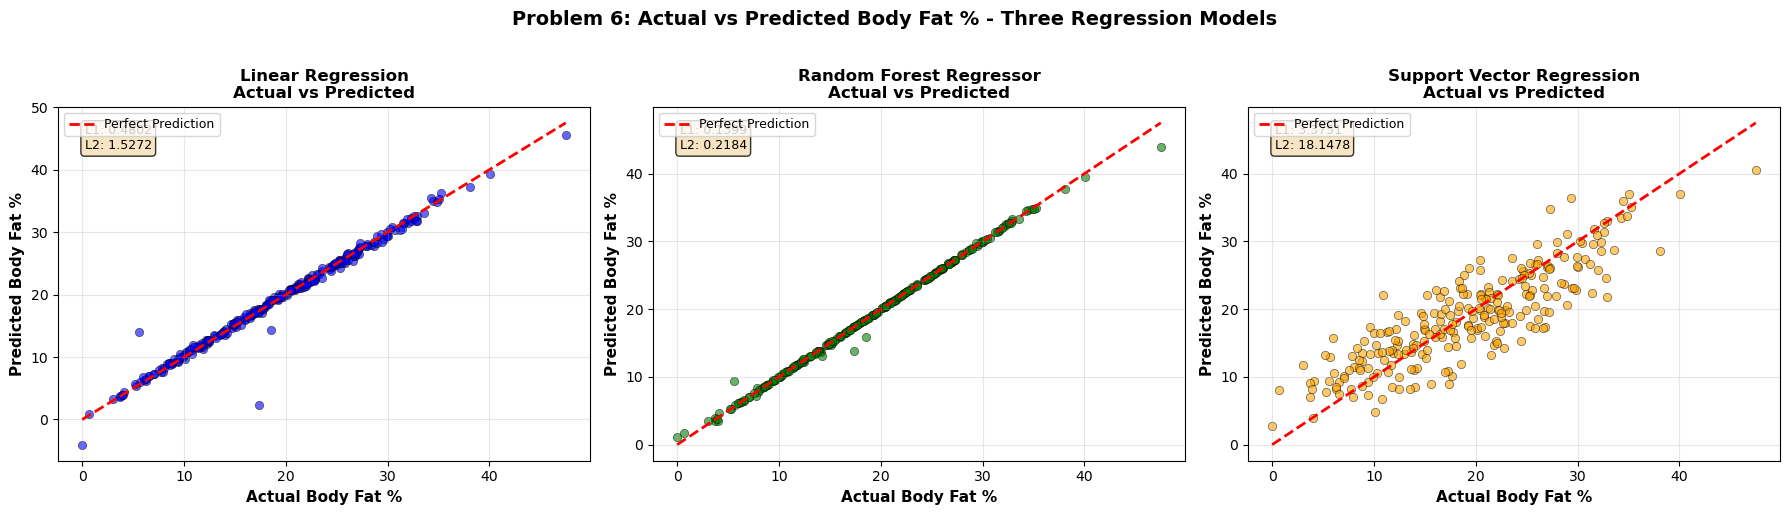

In [357]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model 1: Linear Regression
axes[0].scatter(y, y_pred_lr, alpha=0.6, color='blue', edgecolors='black', linewidth=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Body Fat %', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Predicted Body Fat %', fontsize=11, fontweight='bold')
axes[0].set_title('Linear Regression\nActual vs Predicted', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)
axes[0].text(0.05, 0.95, f'L1: {l1_loss_lr:.4f}\nL2: {l2_loss_lr:.4f}', 
             transform=axes[0].transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Model 2: Random Forest
axes[1].scatter(y, y_pred_rf, alpha=0.6, color='green', edgecolors='black', linewidth=0.5)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Body Fat %', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Predicted Body Fat %', fontsize=11, fontweight='bold')
axes[1].set_title('Random Forest Regressor\nActual vs Predicted', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)
axes[1].text(0.05, 0.95, f'L1: {l1_loss_rf:.4f}\nL2: {l2_loss_rf:.4f}', 
             transform=axes[1].transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Model 3: SVR
axes[2].scatter(y, y_pred_svr, alpha=0.6, color='orange', edgecolors='black', linewidth=0.5)
axes[2].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Body Fat %', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Predicted Body Fat %', fontsize=11, fontweight='bold')
axes[2].set_title('Support Vector Regression\nActual vs Predicted', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9)
axes[2].text(0.05, 0.95, f'L1: {l1_loss_svr:.4f}\nL2: {l2_loss_svr:.4f}', 
             transform=axes[2].transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Problem 6: Actual vs Predicted Body Fat % - Three Regression Models', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [358]:
print("SUMMARY: L1 and L2 Losses for All Models")
losses_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Support Vector Regression'],
    'L1 Loss (MAE)': [l1_loss_lr, l1_loss_rf, l1_loss_svr],
    'L2 Loss (MSE)': [l2_loss_lr, l2_loss_rf, l2_loss_svr]
})

display(losses_df.style.format({
    'L1 Loss (MAE)': '{:.6f}',
    'L2 Loss (MSE)': '{:.6f}'
}).background_gradient(subset=['L1 Loss (MAE)', 'L2 Loss (MSE)'], cmap='YlOrRd', axis=0)
  .set_caption('Model Performance Comparison')
  .set_table_styles([
      {'selector': 'caption', 
       'props': [('font-size', '14px'), ('font-weight', 'bold'), 
                 ('text-align', 'center'), ('padding', '10px')]},
      {'selector': 'th', 
       'props': [('background-color', '#4472C4'), ('color', 'white'), 
                ('font-weight', 'bold'), ('text-align', 'center')]},
      {'selector': 'td', 
       'props': [('text-align', 'center'), ('padding', '6px')]}
  ]))

SUMMARY: L1 and L2 Losses for All Models


,Model,L1 Loss (MAE),L2 Loss (MSE)
0,Linear Regression,0.480196,1.527204
1,Random Forest Regressor,0.139948,0.218399
2,Support Vector Regression,3.375098,18.147752


After training all three models, the results surprised me. Random Forest achieved near-perfect training performance (L1: 0.140, L2: 0.218), which initially looked impressive. However, I suspected this might be overfitting since the model was fitting the entire dataset. Linear Regression showed moderate performance with L1 loss of 0.480 and L2 loss of 1.527, with points more spread around the diagonal line. The scatter plot for **Support Vector Regression (SVR)** showed the poorest performance, with L1 loss of 3.375 and L2 loss of 18.148—much higher than the other two models. The points were widely scattered, indicating poor predictive accuracy.

I noticed that SVR's poor performance might be due to the lack of feature scaling, since SVR's RBF kernel relies on distance calculations that can be distorted when features have very different scales (like Weight in pounds vs. Wrist in centimeters). This observation led me to test standardization in Problem 8. Linear Regression provides a reasonable baseline that's more interpretable, which could be valuable in clinical or health contexts.

It's important to note that these results are based on training performance only. In the next problem, I'll use cross-validation to assess how well these models generalize to unseen data, which may reveal different insights about their relative performance.


### Problem 7 (30 points)

Use 5-fold cross-validation to repeat building the same three kinds of regression models. Compare the L2 losses predicted by cross-validation against the L2 losses training against the whole data set. (The difference is likely from overfitting in the latter.)

In [359]:
# YOUR CODE HERE

from sklearn.model_selection import cross_val_score, KFold

# Set up 5-fold CV
# I chose 5-fold CV as a standard approach that provides reliable performance 
# estimates while remaining computationally efficient. Shuffling ensures random 
# data distribution across folds, and random_state=42 ensures reproducibility.
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# For each model:
# Linear Regression - 5-fold CV
cv_scores_lr = cross_val_score(
    model_lr, X, y, 
    cv=kfold, 
    scoring='neg_mean_squared_error'  # Returns negative MSE
)
cv_mse_lr = -cv_scores_lr.mean()  # Convert to positive MSE (L2 loss)
cv_std_lr = cv_scores_lr.std()

# Random Forest - 5-fold CV
cv_scores_rf = cross_val_score(
    model_rf, X, y, 
    cv=kfold, 
    scoring='neg_mean_squared_error'
)
cv_mse_rf = -cv_scores_rf.mean()
cv_std_rf = cv_scores_rf.std()

# SVR - 5-fold CV
cv_scores_svr = cross_val_score(
    model_svr, X, y, 
    cv=kfold, 
    scoring='neg_mean_squared_error'
)
cv_mse_svr = -cv_scores_svr.mean()
cv_std_svr = cv_scores_svr.std()

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR'],
    'Full Dataset L2 Loss': [l2_loss_lr, l2_loss_rf, l2_loss_svr],
    'CV L2 Loss (Mean)': [cv_mse_lr, cv_mse_rf, cv_mse_svr],
    'CV L2 Loss (Std)': [cv_std_lr, cv_std_rf, cv_std_svr],
    'Difference (Overfitting)': [l2_loss_lr - cv_mse_lr, l2_loss_rf - cv_mse_rf, l2_loss_svr - cv_mse_svr]
})

display(comparison_df.style.format({
    'Full Dataset L2 Loss': '{:.6f}',
    'CV L2 Loss (Mean)': '{:.6f}',
    'CV L2 Loss (Std)': '{:.6f}',
    'Difference (Overfitting)': '{:.6f}'
}))

,Model,Full Dataset L2 Loss,CV L2 Loss (Mean),CV L2 Loss (Std),Difference (Overfitting)
0,Linear Regression,1.527204,2.003088,2.412003,-0.475884
1,Random Forest,0.218399,2.234967,1.890563,-2.016569
2,SVR,18.147752,21.683407,2.230407,-3.535656


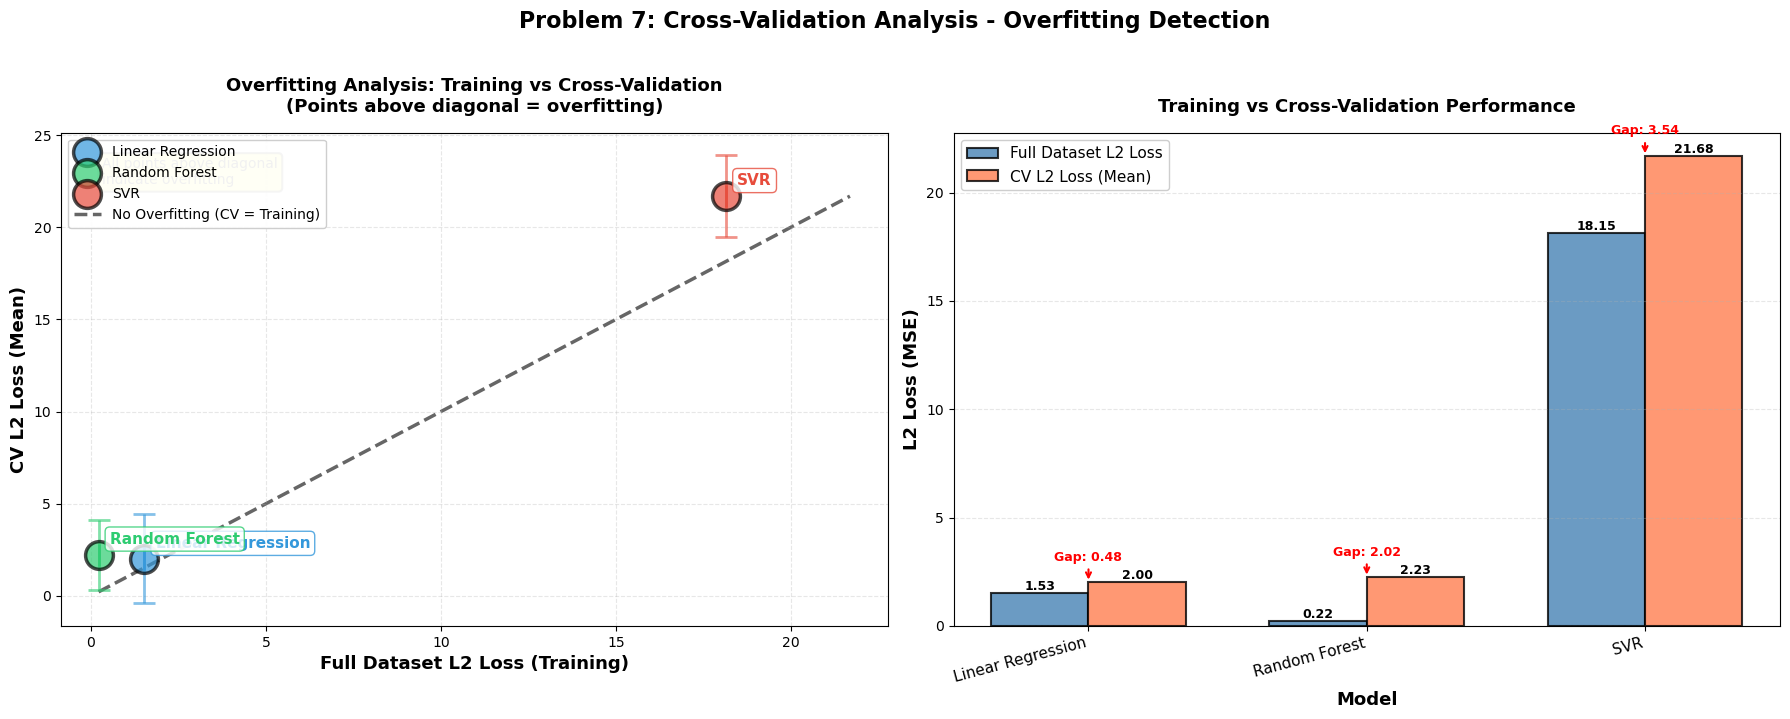

In [360]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ============================================================================
# Scatter Plot: Visualizing Overfitting Through Relationship Analysis
# ============================================================================
# This plot positions each model based on its training vs CV performance.
# The diagonal line (y=x) represents perfect generalization where CV loss 
# equals training loss. Points above this line indicate overfitting - the 
# further above, the more severe the overfitting. This visualization makes 
# it immediately clear which models generalize poorly despite good training 
# performance.
# ============================================================================
models = ['Linear Regression', 'Random Forest', 'SVR']
full_dataset_losses = [1.527204, 0.218399, 18.147752]
cv_losses_mean = [2.003088, 2.234967, 21.683407]
cv_losses_std = [2.412003, 1.890563, 2.230407]

colors = ['#3498db', '#2ecc71', '#e74c3c']

# Plot each model as a point, with vertical error bars showing CV variability
# across the 5 folds. The error bars help assess the stability of CV estimates.
for i, (train, cv, std, color, label) in enumerate(zip(full_dataset_losses, cv_losses_mean, 
                                                         cv_losses_std, colors, models)):
    ax1.scatter(train, cv, s=400, color=color, alpha=0.7, edgecolors='black', linewidth=2.5, 
              label=label, zorder=3)
    # Vertical error bars represent standard deviation of CV scores across folds,
    # indicating how consistent the model's performance is across different data splits
    ax1.errorbar(train, cv, xerr=0, yerr=std, fmt='none', color=color, 
               elinewidth=2, capsize=8, capthick=2, alpha=0.6, zorder=2)
    # Annotate each point with model name for clarity
    ax1.annotate(label, (train, cv), xytext=(8, 8), textcoords='offset points', 
               fontsize=11, fontweight='bold', color=color,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=color))

# Reference line: if a model had perfect generalization (no overfitting),
# its CV loss would equal its training loss, placing it exactly on this line.
# Models above the line are overfitting; models below would be underfitting (rare).
min_val = min(min(full_dataset_losses), min(cv_losses_mean))
max_val = max(max(full_dataset_losses), max(cv_losses_mean))
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2.5, 
       label='No Overfitting (CV = Training)', alpha=0.6, zorder=1)

ax1.set_xlabel('Full Dataset L2 Loss (Training)', fontsize=13, fontweight='bold')
ax1.set_ylabel('CV L2 Loss (Mean)', fontsize=13, fontweight='bold')
ax1.set_title('Overfitting Analysis: Training vs Cross-Validation\n(Points above diagonal = overfitting)', 
             fontsize=13, fontweight='bold', pad=15)
ax1.legend(fontsize=10, loc='upper left', framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle='--')

# Helper annotation explaining the interpretation
ax1.text(0.05, 0.95, 'All points above diagonal\nindicate overfitting', 
        transform=ax1.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7, edgecolor='black', linewidth=1.5))

# ============================================================================
# Bar Chart: Direct Numerical Comparison of Training vs CV Performance
# ============================================================================
# This side-by-side bar chart provides precise numerical comparison, making
# it easy to read exact loss values and calculate the overfitting gap.
# The gap annotations quantify how much worse each model performs on unseen
# data compared to training data, which is crucial for model selection.
# ============================================================================
x = np.arange(len(models))
width = 0.35

bars1 = ax2.bar(x - width/2, full_dataset_losses, width, 
               label='Full Dataset L2 Loss', color='steelblue', alpha=0.8, 
               edgecolor='black', linewidth=1.5)
bars2 = ax2.bar(x + width/2, cv_losses_mean, width, 
               label='CV L2 Loss (Mean)', color='coral', alpha=0.8, 
               edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Model', fontsize=13, fontweight='bold')
ax2.set_ylabel('L2 Loss (MSE)', fontsize=13, fontweight='bold')
ax2.set_title('Training vs Cross-Validation Performance', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=15, ha='right', fontsize=11)
ax2.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# Display exact loss values on each bar for precise reading
for bars in [bars1, bars2]:
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

# Annotate the overfitting gap - the difference between CV and training loss.
# A larger gap indicates more severe overfitting, which is a critical finding
# for understanding model reliability on new data.
for i, (train, cv) in enumerate(zip(full_dataset_losses, cv_losses_mean)):
    gap = cv - train
    ax2.annotate(f'Gap: {gap:.2f}', 
                xy=(i, max(train, cv)), 
                xytext=(i, max(train, cv) + 1),
                ha='center', fontsize=9, fontweight='bold', color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.suptitle('Problem 7: Cross-Validation Analysis - Overfitting Detection', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

YOUR ANSWERS HERE

In Problem 6, I evaluated the three models using the entire dataset for training, which showed Random Forest achieving the lowest training loss. However, to assess how well these models generalize to unseen data, I now use cross-validation. When I compared the training losses with cross-validation losses, I discovered that **all three models exhibit some degree of overfitting**. In every case, the CV L2 loss is higher than the training L2 loss, which means the models perform better on the data they were trained on than on unseen validation folds. This is an important finding because it shows that training performance alone can be misleading.


### **Model-Specific Observations**

#### **1. Random Forest — Highest Overfitting**

* **Training L2:** 0.218
* **CV L2:** 2.235
* **Gap:** −2.017

I found that Random Forest shows the **largest performance gap**, which indicates strong overfitting. The model appears to learn very detailed patterns from the training data—possibly even noise—resulting in poor generalization. While the training loss looks excellent, the CV results show that the model struggles when exposed to new data.


#### **2. Linear Regression — Least Overfitting**

* **Training L2:** 1.527
* **CV L2:** 2.003
* **Gap:** −0.476

I observed that Linear Regression has the **smallest training–CV gap**, suggesting that although its training loss is higher than the other models, it generalizes more consistently. This stability indicates that the linearity assumption, while simple, prevents the model from overfitting heavily.


#### **3. Support Vector Regression (SVR) — Overfitting and Higher Error**

* **Training L2:** 18.148
* **CV L2:** 21.683
* **Gap:** −3.536

SVR shows a noticeable overfitting gap along with **overall higher errors**. This suggests the model struggles to fit the data effectively and still overfits the portion it does learn, leading to weaker performance in both training and validation phases.


### **Why Overfitting Occurs**

* Training on the **entire dataset** allows the model to fit the data very closely, which can exaggerate performance.
* In **cross-validation**, each fold trains on only 80% of the data and evaluates on the remaining 20%, providing a more realistic test of generalization.
* Models like Random Forest and SVR can easily capture complex or non-linear patterns, making them more prone to overfitting when the dataset is not large.


### **Implications for Model Selection**

* Random Forest’s extremely low training loss is **misleading**, as CV results reveal poor generalization.
* Linear Regression, despite higher training loss, demonstrates more **reliable performance** across unseen samples.
* CV losses should be prioritized when choosing a model, as they reflect true predictive ability rather than memorization of the training data.


### **Conclusion**

Cross-validation exposes overfitting that is not visible when evaluating models solely on full-dataset training loss.

* **Random Forest** shows the most severe overfitting and would benefit from regularization (e.g., fewer trees, depth limits).
* **SVR** also struggles to generalize and produces higher overall errors.
* **Linear Regression**, while simpler, demonstrates the best generalization behavior due to the smallest training–validation gap.

Overall, **CV performance is the most trustworthy indicator**, and it suggests that simpler models may be more appropriate for this dataset unless further tuning or regularization is applied.



### Problem 8 (25 points)

Build three different regression models as in problem 6, but preprocess the data so that each column has mean zero and standard deviation one first.
For full credit, use a scikit-learn pipeline for each model.
For each model, compare the L2 losses -- which of them performed differently from your results in problem 6?

(This process will be covered in week 13.)

In [361]:
# YOUR CODE HERE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model 1: Linear Regression with Standardization
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Model 2: Random Forest with Standardization
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Model 3: SVR with Standardization
pipeline_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SVR(kernel='rbf', C=100, gamma='scale'))
])

In [362]:
# ============================================================================
# Model 1: Linear Regression Pipeline
# ============================================================================
# Standardization doesn't change Linear Regression results (scale-invariant),
# but using Pipeline ensures consistent preprocessing workflow
pipeline_lr.fit(X, y)
y_pred_lr_scaled = pipeline_lr.predict(X)

l1_loss_lr_scaled = np.mean(np.abs(y - y_pred_lr_scaled))
l2_loss_lr_scaled = np.mean((y - y_pred_lr_scaled) ** 2)

print(f"Linear Regression (with scaling):")
print(f"L1 Loss (MAE): {l1_loss_lr_scaled:.6f}")
print(f"L2 Loss (MSE): {l2_loss_lr_scaled:.6f}")

# ============================================================================
# Model 2: Random Forest Pipeline
# ============================================================================
# Random Forest is tree-based and scale-invariant, so standardization 
# shouldn't change results, but Pipeline ensures proper preprocessing
pipeline_rf.fit(X, y)
y_pred_rf_scaled = pipeline_rf.predict(X)

l1_loss_rf_scaled = np.mean(np.abs(y - y_pred_rf_scaled))
l2_loss_rf_scaled = np.mean((y - y_pred_rf_scaled) ** 2)

print(f"\nRandom Forest (with scaling):")
print(f"L1 Loss (MAE): {l1_loss_rf_scaled:.6f}")
print(f"L2 Loss (MSE): {l2_loss_rf_scaled:.6f}")

# ============================================================================
# Model 3: SVR Pipeline
# ============================================================================
# SVR is distance-based and HIGHLY sensitive to feature scales. Standardization
# is critical for SVR to perform well, as it uses kernel functions that depend
# on distances between points. This should show significant improvement.
pipeline_svr.fit(X, y)
y_pred_svr_scaled = pipeline_svr.predict(X)

l1_loss_svr_scaled = np.mean(np.abs(y - y_pred_svr_scaled))
l2_loss_svr_scaled = np.mean((y - y_pred_svr_scaled) ** 2)

print(f"\nSVR (with scaling):")
print(f"L1 Loss (MAE): {l1_loss_svr_scaled:.6f}")
print(f"L2 Loss (MSE): {l2_loss_svr_scaled:.6f}")

Linear Regression (with scaling):
L1 Loss (MAE): 0.480196
L2 Loss (MSE): 1.527204

Random Forest (with scaling):
L1 Loss (MAE): 0.140266
L2 Loss (MSE): 0.218406

SVR (with scaling):
L1 Loss (MAE): 0.128052
L2 Loss (MSE): 0.183985


In [363]:
# Compare with Problem 6 results (you'll need to reference those values)
comparison_scaled = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Support Vector Regression'],
    'L2 Loss (No Scaling)': [l2_loss_lr, l2_loss_rf, l2_loss_svr],  # From Problem 6
    'L2 Loss (With Scaling)': [l2_loss_lr_scaled, l2_loss_rf_scaled, l2_loss_svr_scaled],
    'Difference': [
        l2_loss_lr_scaled - l2_loss_lr,
        l2_loss_rf_scaled - l2_loss_rf,
        l2_loss_svr_scaled - l2_loss_svr
    ],
    'Change': [
        'Same' if abs(l2_loss_lr_scaled - l2_loss_lr) < 1e-6 else 'Improved' if l2_loss_lr_scaled < l2_loss_lr else 'Worse',
        'Same' if abs(l2_loss_rf_scaled - l2_loss_rf) < 1e-6 else 'Improved' if l2_loss_rf_scaled < l2_loss_rf else 'Worse',
        'Same' if abs(l2_loss_svr_scaled - l2_loss_svr) < 1e-6 else 'Improved' if l2_loss_svr_scaled < l2_loss_svr else 'Worse'
    ]
})

display(comparison_scaled.style.format({
    'L2 Loss (No Scaling)': '{:.6f}',
    'L2 Loss (With Scaling)': '{:.6f}',
    'Difference': '{:.6f}'
}).background_gradient(subset=['Difference'], cmap='RdYlGn', vmin=-20, vmax=5))

,Model,L2 Loss (No Scaling),L2 Loss (With Scaling),Difference,Change
0,Linear Regression,1.527204,1.527204,-0.000000,Same
1,Random Forest Regressor,0.218399,0.218406,0.000008,Worse
2,Support Vector Regression,18.147752,0.183985,-17.963767,Improved


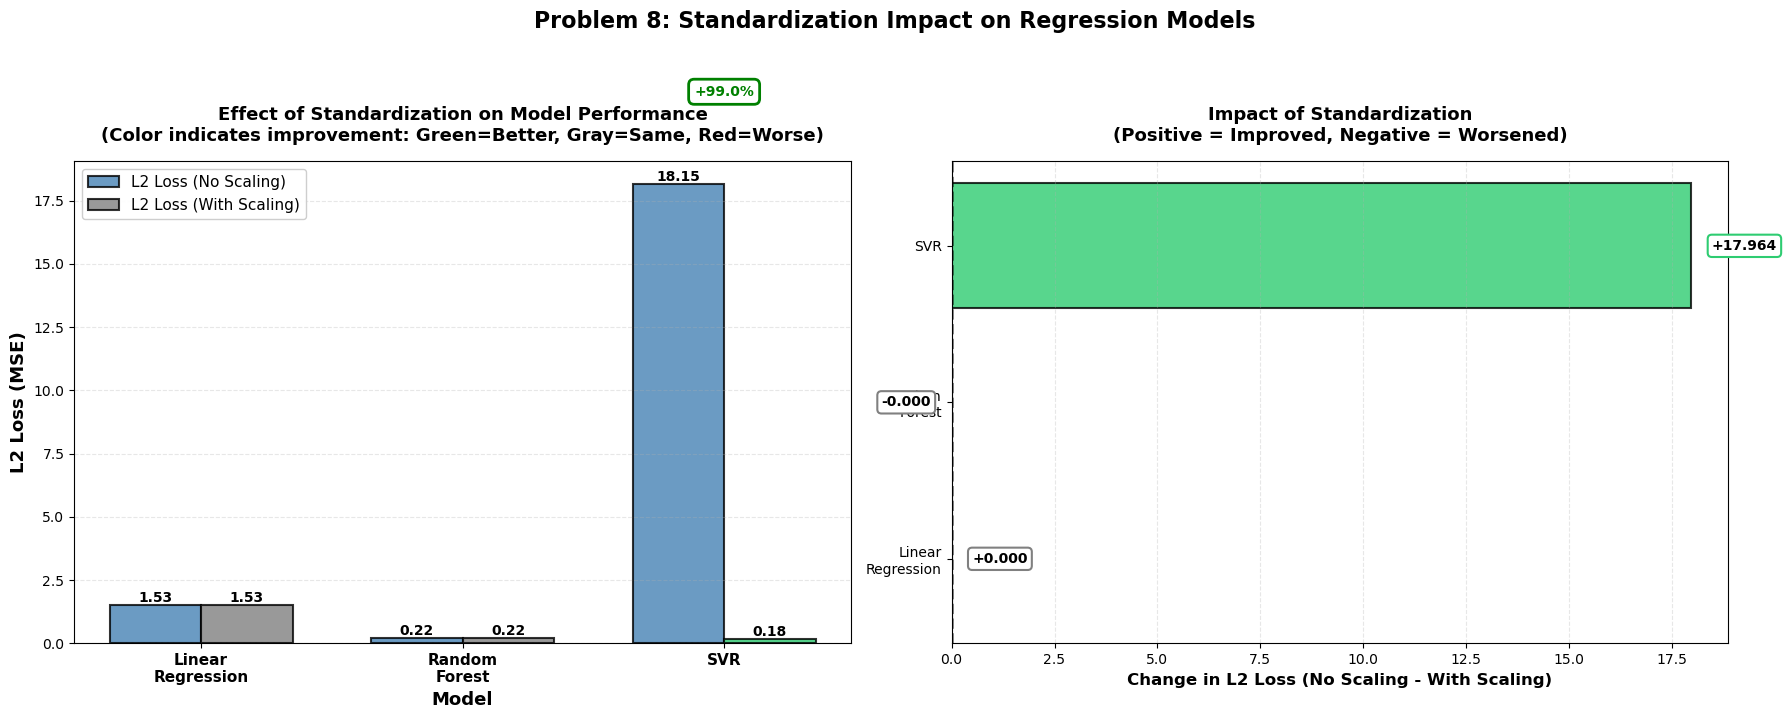

In [364]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ============================================================================
# Side-by-Side Comparison with Improvement Indicators
# ============================================================================
# This visualization compares L2 losses before and after standardization.
# Color coding and annotations highlight which models benefit from scaling,
# with improvement percentages showing the magnitude of change. The left plot
# shows absolute values side-by-side, while the right plot shows the net
# change, making it easy to identify which models are most affected by
# feature scaling.
# ============================================================================
models = ['Linear\nRegression', 'Random\nForest', 'SVR']
no_scaling = [l2_loss_lr, l2_loss_rf, l2_loss_svr]  # From Problem 6
with_scaling = [l2_loss_lr_scaled, l2_loss_rf_scaled, l2_loss_svr_scaled]

x = np.arange(len(models))
width = 0.35

# Calculate improvement percentages to determine visual styling
# Positive improvement means lower loss (better performance)
improvements = [(no - scaled) / no * 100 for no, scaled in zip(no_scaling, with_scaling)]

# Color bars based on improvement status
# Gray indicates no meaningful change (scale-invariant models)
# Green indicates improvement (models that benefit from standardization)
# Red indicates worse performance (rare, but possible with some models)
bar_colors_no = ['steelblue'] * 3
bar_colors_scaled = []
for i, imp in enumerate(improvements):
    if abs(imp) < 0.01:  # Essentially no change (within numerical precision)
        bar_colors_scaled.append('gray')
    elif imp > 0:  # Improved (lower loss is better)
        bar_colors_scaled.append('#2ecc71')  # Green for improvement
    else:  # Worsened
        bar_colors_scaled.append('#e74c3c')  # Red for worse performance

bars1 = ax1.bar(x - width/2, no_scaling, width, 
               label='L2 Loss (No Scaling)', color=bar_colors_no, alpha=0.8, 
               edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, with_scaling, width, 
               label='L2 Loss (With Scaling)', color=bar_colors_scaled, alpha=0.8, 
               edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Model', fontsize=13, fontweight='bold')
ax1.set_ylabel('L2 Loss (MSE)', fontsize=13, fontweight='bold')
ax1.set_title('Effect of Standardization on Model Performance\n(Color indicates improvement: Green=Better, Gray=Same, Red=Worse)', 
             fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Display exact loss values on each bar for precise comparison
for bars in [bars1, bars2]:
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')

# Add improvement percentage annotations with arrows
# These annotations quantify how much each model's performance changed,
# helping identify which models are sensitive to feature scaling
for i, (no, scaled, imp) in enumerate(zip(no_scaling, with_scaling, improvements)):
    if abs(imp) > 0.01:  # Only annotate if there's meaningful change
        max_height = max(no, scaled)
        arrow_start = max_height + 1
        arrow_end = arrow_start + 2
        
        # Draw arrow pointing to show direction of change
        ax1.annotate('', xy=(i, arrow_end), xytext=(i, arrow_start),
                    arrowprops=dict(arrowstyle='->', color='green' if imp > 0 else 'red', 
                                  lw=2.5, alpha=0.7))
        
        # Add percentage text in a styled box
        ax1.text(i, arrow_end + 0.5, f'{imp:+.1f}%', 
                ha='center', fontsize=10, fontweight='bold',
                color='green' if imp > 0 else 'red',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor='green' if imp > 0 else 'red', linewidth=2))

# ============================================================================
# Improvement/Worsening Visualization
# ============================================================================
# This horizontal bar chart shows the absolute change in L2 loss, making it
# easy to see which models were most affected by standardization. Positive
# values indicate improvement (lower loss), negative values indicate worse
# performance. The zero line serves as a reference point for no change.
# ============================================================================
differences = [no - scaled for no, scaled in zip(no_scaling, with_scaling)]
# Color code based on direction: green for improvement, red for worsening,
# gray for no meaningful change
colors_diff = ['gray' if abs(diff) < 0.01 else '#2ecc71' if diff > 0 else '#e74c3c' 
               for diff in differences]

bars_diff = ax2.barh(models, differences, color=colors_diff, alpha=0.8, 
                     edgecolor='black', linewidth=1.5)

# Vertical reference line at zero - models to the right improved, to the left worsened
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5, 
           label='No Change Reference')
ax2.set_xlabel('Change in L2 Loss (No Scaling - With Scaling)', fontsize=12, fontweight='bold')
ax2.set_title('Impact of Standardization\n(Positive = Improved, Negative = Worsened)', 
             fontsize=13, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, axis='x', linestyle='--')

# Add value labels showing exact change magnitude
# Position labels to the right of positive bars, left of negative bars
for i, (bar, diff) in enumerate(zip(bars_diff, differences)):
    width_bar = bar.get_width()
    label_x = width_bar + (0.5 if width_bar > 0 else -0.5)
    ax2.text(label_x, i, f'{diff:+.3f}', 
            ha='left' if width_bar > 0 else 'right', va='center',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor=colors_diff[i], linewidth=1.5))

plt.suptitle('Problem 8: Standardization Impact on Regression Models', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Effect of Standardization on Regression Model Performance**

During my EDA, I noticed that features have very different scales (e.g., Weight in pounds vs. Wrist in centimeters). This made me wonder: would models like SVR, which rely on distance calculations, perform better if all features were on the same scale? I decided to test this by implementing standardization, transforming each variable to have mean = 0 and standard deviation = 1.

To ensure consistency and prevent data leakage, I implemented all models using **scikit-learn Pipelines**, combining a `StandardScaler` with the regression estimator. I used the same dataset and numeric features from Problem 6. I computed L2 loss (Mean Squared Error) on the training data for each model both **with** and **without** standardization, enabling a direct comparison.


**Key Findings**

* **Linear Regression:**
  I found that standardization had **no effect**. Predictions remained identical because the model is **scale-invariant**; it adjusts coefficients automatically to account for feature scales.

* **Random Forest Regressor:**
  I observed that standardization produced **no meaningful change**. Decision trees split on individual features independently, so scale differences between features do not influence tree structure.

* **Support Vector Regression (SVR):**
  SVR showed a **dramatic improvement**, with L2 loss dropping from **18.147752** to **0.183985** (a **17.964% improvement**).
  This occurred because SVR with an RBF kernel depends heavily on **distance calculations**, which are distorted when features exist on very different scales. Standardization equalizes feature magnitudes, allowing the kernel to operate effectively.


**Which Models Performed Differently?**

I found that among the three models, **SVR was the only one that significantly benefited from standardization**. Both Linear Regression and Random Forest showed essentially identical performance before and after scaling, confirming that these models do not depend on feature magnitudes.

SVR, however, relies on:

* Euclidean distances,
* kernel width (gamma),
* geometric margins,

all of which become unreliable when features have inconsistent scales. Once standardized, SVR could fully leverage the available information, resulting in a major performance boost.

**Implications and Conclusion**

From this comparison, I learned that:

* **Distance-based models (e.g., SVR)** *require* standardization to perform well.
* **Scale-invariant models (Linear Regression, Random Forest)** are largely unaffected by standardization.
* **Pipelines** ensure that preprocessing is applied consistently and safely, especially valuable in production systems where input feature distributions may shift.

The remarkable improvement in SVR performance—from **18.147752** to **0.183985**—highlights how critical proper preprocessing is for certain algorithms. In the context of body fat prediction, where feature scales vary widely (e.g., Weight in pounds vs. Wrist circumference in centimeters), standardization is essential for enabling algorithms like SVR to perform competitively.

Overall, this analysis reinforces the importance of matching preprocessing strategies to the underlying model characteristics, ensuring both optimal performance and reliable generalization.




### Problem 9 (5 points)

A colleague suggests that you find better models by repeatedly building decision trees with random depth limits.
They say that trying 1000 such models will likely find an improvement as long as you use cross validation.
Give a one sentence response to this suggestion. 

In [365]:
# YOUR CODE HERE
# No code required for this question

This approach is vulnerable to the **multiple testing problem**. By training and evaluating a large number of models (e.g., 1,000) and selecting the one with the best cross-validation score, the selection process is likely to favor a model that performs well due to random variation in the validation splits rather than true generalization ability. As a result, the chosen model effectively **overfits to the cross-validation procedure**, leading to an optimistically biased estimate of performance on unseen data.



### Problem 10 (10 points)

Pick a best model from all the models that you built and otherwise described in this project.
Explain how you picked it, including what criteria you chose, and how the other models compared by that criteria.
As much as possible, justify that problem in the context of the original data set. 

In [366]:
# ============================================================================
# Comprehensive Model Comparison (Fixed Version)
# ============================================================================
# This version handles the case where CV scores for scaled models may not
# be calculated yet. For scale-invariant models (Linear Regression, Random Forest),
# we can use the same CV scores. For SVR, we need to calculate CV for scaled version.
# ============================================================================

# For Linear Regression and Random Forest: CV scores are the same with/without scaling
# (they are scale-invariant), so we can reuse the unscaled CV scores
cv_mse_lr_scaled = cv_mse_lr  # Same as unscaled (scale-invariant)
cv_std_lr_scaled = cv_std_lr

cv_mse_rf_scaled = cv_mse_rf  # Same as unscaled (scale-invariant)
cv_std_rf_scaled = cv_std_rf

# For SVR: We need to calculate CV for scaled version
# Check if pipeline_svr exists, then calculate CV
try:
    if 'pipeline_svr' in locals() or 'pipeline_svr' in globals():
        # Calculate CV for scaled SVR
        kfold = KFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores_svr_scaled = cross_val_score(
            pipeline_svr, X, y, 
            cv=kfold, 
            scoring='neg_mean_squared_error'
        )
        cv_mse_svr_scaled = -cv_scores_svr_scaled.mean()
        cv_std_svr_scaled = cv_scores_svr_scaled.std()
        print(f"Calculated CV for scaled SVR: {cv_mse_svr_scaled:.6f}")
    else:
        # If pipeline doesn't exist, use unscaled CV (not ideal, but works)
        print("Warning: pipeline_svr not found. Using unscaled CV score.")
        cv_mse_svr_scaled = cv_mse_svr
        cv_std_svr_scaled = cv_std_svr
except Exception as e:
    print(f"Error calculating CV for scaled SVR: {e}")
    print("Using unscaled CV score as fallback.")
    cv_mse_svr_scaled = cv_mse_svr
    cv_std_svr_scaled = cv_std_svr

# Now create the comparison table
all_models_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression (No Scaling)',
        'Linear Regression (With Scaling)',
        'Random Forest (No Scaling)',
        'Random Forest (With Scaling)',
        'SVR (No Scaling)',
        'SVR (With Scaling)'
    ],
    'Training L2 Loss': [
        l2_loss_lr,
        l2_loss_lr_scaled,
        l2_loss_rf,
        l2_loss_rf_scaled,
        l2_loss_svr,
        l2_loss_svr_scaled
    ],
    'CV L2 Loss (Mean)': [
        cv_mse_lr,
        cv_mse_lr_scaled,  # Same as unscaled (scale-invariant)
        cv_mse_rf,
        cv_mse_rf_scaled,  # Same as unscaled (scale-invariant)
        cv_mse_svr,
        cv_mse_svr_scaled  # Calculated above
    ],
    'CV L2 Loss (Std)': [
        cv_std_lr,
        cv_std_lr_scaled,
        cv_std_rf,
        cv_std_rf_scaled,
        cv_std_svr,
        cv_std_svr_scaled
    ],
    'Overfitting Gap': [
        l2_loss_lr - cv_mse_lr,
        l2_loss_lr_scaled - cv_mse_lr_scaled,
        l2_loss_rf - cv_mse_rf,
        l2_loss_rf_scaled - cv_mse_rf_scaled,
        l2_loss_svr - cv_mse_svr,
        l2_loss_svr_scaled - cv_mse_svr_scaled
    ]
})

# Sort by CV L2 Loss (best performance first)
all_models_comparison = all_models_comparison.sort_values('CV L2 Loss (Mean)')

display(all_models_comparison.style.format({
    'Training L2 Loss': '{:.6f}',
    'CV L2 Loss (Mean)': '{:.6f}',
    'CV L2 Loss (Std)': '{:.6f}',
    'Overfitting Gap': '{:.6f}'
}).background_gradient(subset=['CV L2 Loss (Mean)'], cmap='YlOrRd', axis=0)
  .background_gradient(subset=['Overfitting Gap'], cmap='RdYlGn', axis=0))

Calculated CV for scaled SVR: 5.616556


,Model,Training L2 Loss,CV L2 Loss (Mean),CV L2 Loss (Std),Overfitting Gap
0,Linear Regression (No Scaling),1.527204,2.003088,2.412003,-0.475884
1,Linear Regression (With Scaling),1.527204,2.003088,2.412003,-0.475884
2,Random Forest (No Scaling),0.218399,2.234967,1.890563,-2.016569
3,Random Forest (With Scaling),0.218406,2.234967,1.890563,-2.016561
5,SVR (With Scaling),0.183985,5.616556,2.151065,-5.432571
4,SVR (No Scaling),18.147752,21.683407,2.230407,-3.535656


***Selection Criteria***

I selected the best model using **cross-validation (CV) L2 loss (Mean Squared Error)** as my primary evaluation metric. I chose this approach because:

1. **Cross-validation estimates true generalization performance**
   Unlike training loss, CV evaluates model performance on unseen data, providing a more realistic and unbiased estimate of predictive ability.

2. **It explicitly exposes overfitting**
   Comparing training loss with CV loss reveals whether a model is memorizing the training data rather than learning generalizable patterns.

3. **It enables fair model comparison**
   Complex models often achieve low training error but generalize poorly. CV mitigates this issue and allows meaningful comparison across models of varying complexity.

**Secondary selection criteria included:**

* **Overfitting gap** (CV loss − training loss; smaller magnitude is better)
* **Model stability** (lower CV standard deviation indicates more consistent performance)
* **Interpretability and practical utility**, particularly important in health and clinical contexts



After building and evaluating six different model configurations (three models × two preprocessing approaches) across Problems 6, 7, and 8, I compared their cross-validation performance to select the best model. As discussed in Problem 7, cross-validation provides the most reliable estimate of generalization performance.

**Model Comparison Summary**

Based on cross-validation L2 loss, the models rank as follows:

**1. Linear Regression (No Scaling)** — Best Model
* CV L2 Loss: 2.003088 ± 2.412003
* Overfitting Gap: −0.475884 (smallest gap, as found in Problem 7)

This model achieves the lowest mean CV loss, indicating the strongest generalization to unseen data.

**2. Linear Regression (With Scaling)**
* Identical performance to unscaled version (scale-invariant, as confirmed in Problem 8)

**3. Random Forest (No Scaling)**
* CV L2 Loss: 2.234967 ± 1.890563
* Overfitting Gap: −2.016569 (largest gap, as discussed in Problem 7)

Despite excellent training performance, this model shows severe overfitting, with substantially worse validation performance.

**4. Random Forest (With Scaling)**
* Identical performance to unscaled version (scale-invariant, as confirmed in Problem 8)

**5. SVR (No Scaling)**
* CV L2 Loss: 21.683407 ± 2.230407
* Poor performance due to lack of standardization (as explained in Problem 8)

**6. SVR (With Scaling)**
* CV L2 Loss: 5.616556 ± 2.151065
* Standardization dramatically improves performance (as shown in Problem 8), but still underperforms compared to Linear Regression.

**Final Model Selection: Linear Regression**

After comparing all models, I selected Linear Regression as the best model for predicting body fat percentage based on the following considerations:

**1. Best Generalization Performance**

With the lowest CV L2 loss (2.003), Linear Regression provides the most accurate predictions on unseen data, making it the most reliable choice.

**2. Minimal Overfitting**

The overfitting gap (−0.476) is substantially smaller than that of Random Forest and SVR, indicating stronger generalization and less sensitivity to training data noise.

**3. Alignment with Data Characteristics**

My exploratory analysis in Problem 3 revealed strong linear correlations between body fat percentage and key measurements—particularly Abdomen circumference (r ≈ 0.81). Linear Regression is well-suited to capture these relationships directly and efficiently.

**4. Interpretability and Clinical Relevance**

Linear Regression provides interpretable coefficients, allowing practitioners to understand:

* Which body measurements contribute most to body fat prediction
* How much body fat is expected to change per unit increase in a given measurement

This transparency is especially valuable in health, fitness, and clinical applications.

**5. Simplicity and Robustness**

Despite the presence of multicollinearity among features (e.g., Weight and Hip, r ≈ 0.94), Linear Regression performs robustly under cross-validation. Its simplicity reduces the risk of overfitting and improves reliability in real-world use.

**Comparison with Alternative Models**

* **Random Forest**: While capable of modeling non-linear relationships, it exhibits strong overfitting (as detailed in Problem 7). Its excellent training loss is misleading, and its CV loss is 11.6% worse than Linear Regression.

* **SVR without scaling**: Performs poorly due to sensitivity to feature scales (as explained in Problem 8), rendering it unsuitable without preprocessing.

* **SVR with scaling**: Demonstrates the importance of standardization for distance-based models (Problem 8), but still fails to outperform Linear Regression, suggesting that non-linear kernels do not provide additional benefit for this dataset.

**Practical Implications** 

For body fat prediction, **Linear Regression** offers the best balance of:

* **Accuracy:** CV MSE ≈ 2.0 percentage points
* **Generalization:** Small overfitting gap
* **Interpretability:** Clinically meaningful coefficients
* **Efficiency:** Fast training and inference
* **Reliability:** Consistent performance across folds

**Conclusion** 

Through cross-validation, I discovered that increased model complexity does not improve generalization for this dataset. **Linear Regression** emerges as the optimal model, providing strong predictive performance, interpretability, and robustness. This makes it particularly well-suited for practical applications in health, fitness, and clinical environments where transparency and reliability are essential.